# Notebook 1: Introduction to Weather Forecasting with CorrDiff

## 1. Overview
   - What is weather forecasting?
   - Why use machine learning for weather forecasting?
   - Introduction to the CorrDiff model and its purpose.

## 2. Understanding the Dataset
   - Overview of the HRRR-Mini dataset.
   - Structure of the dataset (`hrrr_mini_train.nc`).
   - Key variables: input, output, and invariant variables.
   - Data normalization and preprocessing.

## 3. Setting Up the Environment
   - Using the provided Docker container.
   - Installing dependencies and verifying the setup.
   - Running a Jupyter Notebook inside the container.

## 4. Exploring the Repository
   - Key components of the `physicsnemo` repository.
   - Overview of the CorrDiff training pipeline.
   - Understanding the configuration files (`config_training_hrrr_mini_regression.yaml` and `config_training_hrrr_mini_diffusion.yaml`).

## 5. Training the Regression Model
   - What is a regression model in this context?
   - Step-by-step walkthrough of training using `config_training_hrrr_mini_regression.yaml`.
   - Monitoring training progress and saving checkpoints.
## 6. Train the Regression on Custom Data

## 7. Training the Diffusion Model
   - What is a diffusion model, and why is it used here?
   - Step-by-step walkthrough of training using `config_training_hrrr_mini_diffusion.yaml`.
   - Using the regression model checkpoint for diffusion training.

## 8. Practical Exercise
   - Hands-on: Training the regression model on the HRRR-Mini dataset.
   - Hands-on: Training the diffusion model using the regression checkpoint.

## 9. Summary and Next Steps
   - Recap of what was learned.
   - Preparing for the next notebook: Evaluation and inference.

# 1. Overview

## 1.1 What is Weather Forecasting?
Weather forecasting is the process of predicting atmospheric conditions at a specific location and time. It involves analyzing historical weather data, current observations, and numerical models to estimate future weather patterns. Accurate weather forecasting is crucial for various applications, including agriculture, disaster management, transportation, and energy planning.

Traditional weather forecasting relies on physical models of the atmosphere, which solve complex equations based on fluid dynamics and thermodynamics. However, these models can be computationally expensive and may struggle with certain types of predictions, such as localized weather events.

---

## 1.2 Why Use Machine Learning for Weather Forecasting?
Machine learning (ML) offers an alternative approach to weather forecasting by learning patterns directly from data. Instead of relying solely on physical equations, ML models can:
- **Capture complex relationships** in the data that may not be explicitly modeled in traditional approaches.
- **Reduce computational costs** by approximating physical processes.
- **Adapt to specific tasks**, such as predicting rainfall, temperature, or wind speed.

In this repository, we use machine learning models to forecast weather variables based on historical data. Specifically, we focus on the **CorrDiff model**, which combines regression and diffusion techniques to improve prediction accuracy.

---

## 1.3 Introduction to the CorrDiff Model and Its Purpose
The **CorrDiff model** is a machine learning framework designed for weather forecasting. It consists of two main components:
1. **Regression Model**: This model predicts the primary weather variables (e.g., temperature, pressure) based on input data. It serves as the foundation for the forecasting pipeline.
2. **Diffusion Model**: This model refines the predictions by modeling the uncertainty and variability in the data. It uses the output of the regression model as input and generates more accurate and realistic forecasts.

The CorrDiff model is particularly useful for tasks where capturing fine-grained details and uncertainties is essential, such as predicting extreme weather events or localized phenomena.

---

## 1.4 Learning Objectives for This Notebook
By the end of this notebook, you will:
1. Understand the basics of weather forecasting and the role of machine learning.
2. Learn about the CorrDiff model and its components.
3. Set up the environment to train and evaluate the CorrDiff model on the HRRR-Mini dataset.



# 2. Understanding the Dataset

## 2.1 Overview of the HRRR-Mini Dataset

The **HRRR-Mini dataset** is a compact version of the High-Resolution Rapid Refresh (HRRR) dataset, which is widely used in weather forecasting. It contains a subset of weather variables and spatial-temporal data, making it ideal for experimentation and learning.

### Key Features of the HRRR-Mini Dataset:
- **Compact Size**: The dataset is small enough to be used on personal machines while retaining the essential features of the full HRRR dataset.
- **NetCDF Format**: The data is stored in `.nc` (NetCDF) format, which is commonly used for multidimensional scientific data.
- **Training and Testing**: The dataset includes separate files for training and testing, such as `hrrr_mini_train.nc` and `hrrr_mini_test.nc`.

---

## 2.2. Structure of the Dataset (`hrrr_mini_train.nc`)

The dataset is organized into multiple variables, each representing a specific weather feature or metadata. Below is an overview of the key components:

### Dimensions:
- **Time**: The temporal dimension, representing different time steps in the dataset.
- **Latitude**: The spatial dimension for latitude.
- **Longitude**: The spatial dimension for longitude.

### Variables:
1. **Input Variables**:
   - These are the features used as inputs to the model.
   - Examples: Temperature, pressure, wind speed, and humidity.

2. **Output Variables**:
   - These are the target variables the model is trained to predict.
   - Examples: Future temperature, precipitation, or wind speed.

3. **Invariant Variables**:
   - These are static features that do not change over time, such as elevation or land cover.

### Metadata:
- The dataset may also include metadata, such as units of measurement, variable descriptions, and coordinate reference systems.

---

## 2.3. Key Variables: Input, Output, and Invariant Variables

### Input Variables:
- Represent the current state of the atmosphere.
- Examples:
  - `temperature_2m`: Temperature at 2 meters above ground level.
  - `pressure_surface`: Surface pressure.
  - `wind_u_10m` and `wind_v_10m`: Wind components at 10 meters.

### Output Variables:
- Represent the future state of the atmosphere that the model aims to predict.
- Examples:
  - `temperature_2m_future`: Future temperature at 2 meters.
  - `precipitation_accumulated`: Accumulated precipitation over a time period.

### Invariant Variables:
- Provide additional context for the model.
- Examples:
  - `elevation`: Elevation of the terrain.
  - `land_cover`: Type of land cover (e.g., forest, urban).

---

## 2.4. Data Normalization and Preprocessing

### Why Normalize Data?
Normalization ensures that all variables have similar scales, which helps the model converge faster and improves performance. For example:
- Temperature values may range from -50°C to 50°C.
- Wind speed values may range from 0 to 100 m/s.
- Elevation values may range from 0 to 8,000 meters.

### Common Normalization Techniques:
1. **Min-Max Scaling**:
   - Scales data to a range of [0, 1].
   - Formula: `(x - min) / (max - min)`.
2. **Standardization**:
   - Scales data to have a mean of 0 and a standard deviation of 1.
   - Formula: `(x - mean) / std`.

### Preprocessing Steps:
1. **Load the Dataset**:
   - Use Python libraries like `xarray` or `netCDF4` to load the `.nc` file.


In [1]:
ls -lh /app/data/weather_data/hrrr_mini_train.nc 

-rw-r--r-- 1 1018 1018 2.0G Jul 15 06:22 /app/data/weather_data/hrrr_mini_train.nc


In [2]:
import xarray as xr
data_path = "/app/data/weather_data/hrrr_mini_train.nc"
#data_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"
dataset = xr.open_dataset(data_path)
dataset

<xarray.Dataset> Size: 1MB
Dimensions:  (sample: 100000, coord: 2)
Coordinates:
    coord    (sample, coord) uint16 400kB ...
Dimensions without coordinates: sample
Data variables:
    time     (sample) datetime64[ns] 800kB ...

In [3]:
import netCDF4 as nc

# Open the file and list all groups
with nc.Dataset(data_path) as f:
    print("Groups in the file:", list(f.groups.keys()))

Groups in the file: ['input', 'output', 'invariant']


In [4]:
# Load the 'input' group
input_group = xr.open_dataset(data_path, group="input")
input_group


<xarray.Dataset> Size: 666MB
Dimensions:  (sample: 100000, y_lr: 8, x_lr: 8)
Dimensions without coordinates: sample, y_lr, x_lr
Data variables: (12/26)
    u10m     (sample, y_lr, x_lr) float32 26MB ...
    v10m     (sample, y_lr, x_lr) float32 26MB ...
    t2m      (sample, y_lr, x_lr) float32 26MB ...
    tcwv     (sample, y_lr, x_lr) float32 26MB ...
    sp       (sample, y_lr, x_lr) float32 26MB ...
    msl      (sample, y_lr, x_lr) float32 26MB ...
    ...       ...
    t500     (sample, y_lr, x_lr) float32 26MB ...
    t250     (sample, y_lr, x_lr) float32 26MB ...
    q1000    (sample, y_lr, x_lr) float32 26MB ...
    q850     (sample, y_lr, x_lr) float32 26MB ...
    q500     (sample, y_lr, x_lr) float32 26MB ...
    q250     (sample, y_lr, x_lr) float32 26MB ...

In [5]:
# Load the 'output' group
output_group = xr.open_dataset(data_path, group="output")
output_group

<xarray.Dataset> Size: 7GB
Dimensions:  (sample: 100000, y_hr: 64, x_hr: 64)
Dimensions without coordinates: sample, y_hr, x_hr
Data variables:
    2t       (sample, y_hr, x_hr) float32 2GB ...
    10u      (sample, y_hr, x_hr) float32 2GB ...
    10v      (sample, y_hr, x_hr) float32 2GB ...
    tp       (sample, y_hr, x_hr) float32 2GB ...

In [6]:
# Load the 'invariant' group
invariant_group = xr.open_dataset(data_path, group="invariant")
invariant_group

<xarray.Dataset> Size: 30MB
Dimensions:    (y_grid: 1059, x_grid: 1799)
Dimensions without coordinates: y_grid, x_grid
Data variables:
    latitude   (y_grid, x_grid) float32 8MB ...
    longitude  (y_grid, x_grid) float32 8MB ...
    elev_mean  (y_grid, x_grid) float32 8MB ...
    lsm_mean   (y_grid, x_grid) float32 8MB ...

### Understanding the Dataset Structure and Meaning

#### 1. Top-Level Structure
At the top level, the dataset contains:
- **`time`**: A 1D array of timestamps for each sample.
- **`coord`**: A 2D array of coordinates (latitude and longitude) for each sample.

These variables provide metadata for the samples, such as when and where the data was collected.

---

#### 2. Groups
The dataset is divided into three groups: **`input`**, **`output`**, and **`invariant`**. Each group serves a specific purpose:

##### a. `input` Group
This group contains **low-resolution input variables** for each sample. These variables are stored on an 8x8 grid (`y_lr`, `x_lr`) for each sample (`sample` dimension).

###### Dimensions:
- `sample`: Number of samples (100,000).
- `y_lr`, `x_lr`: Low-resolution grid dimensions (8x8).

###### Variables:
- **Wind Components**:
  - `u10m`, `v10m`: 10-meter wind components.
  - `u1000`, `v1000`, `u850`, `v850`, `u500`, `v500`, `u250`, `v250`: Wind components at various pressure levels (1000 hPa, 850 hPa, etc.).
- **Temperature**:
  - `t2m`: 2-meter temperature.
  - `t1000`, `t850`, `t500`, `t250`: Temperature at various pressure levels.
- **Geopotential Height**:
  - `z1000`, `z850`, `z500`, `z250`: Geopotential height at various pressure levels.
- **Specific Humidity**:
  - `q1000`, `q850`, `q500`, `q250`: Specific humidity at various pressure levels.
- **Other Variables**:
  - `tcwv`: Total column water vapor.
  - `sp`: Surface pressure.
  - `msl`: Mean sea level pressure.

###### Purpose:
The `input` group provides the atmospheric conditions (e.g., wind, temperature, pressure) at various levels of the atmosphere on a coarse grid. These are likely used as input features for a weather prediction model.

---

##### b. `output` Group
This group contains **high-resolution output variables** for each sample. These variables are stored on a 64x64 grid (`y_hr`, `x_hr`) for each sample.

###### Dimensions:
- `sample`: Number of samples (100,000).
- `y_hr`, `x_hr`: High-resolution grid dimensions (64x64).

###### Variables:
- **`\2t`**: 2-meter temperature.
- **`\10u`, `\10v`**: 10-meter wind components.
- **`tp`**: Total precipitation.

###### Purpose:
The `output` group provides the high-resolution predictions or observations for each sample. These are likely the target variables for a weather prediction model.

---

##### c. `invariant` Group
This group contains **static geographical data** that does not change over time. These variables are stored on a global grid (`y_grid`, `x_grid`).

###### Dimensions:
- `y_grid`, `x_grid`: Global grid dimensions (1059x1799).

###### Variables:
- **`latitude` and `longitude`**: Latitude and longitude of each grid point.
- **`elev_mean`**: Mean elevation.
- **`lsm_mean`**: Mean land-sea mask (likely a binary or fractional value indicating land or water).

###### Purpose:
The `invariant` group provides static geographical information that can be used as additional context for the weather data (e.g., elevation and land-sea distribution).

---

#### 3. Summary of the Dataset's Organization
- **Top-Level Variables**:
  - `time`: Timestamps for each sample.
  - `coord`: Latitude and longitude for each sample.
- **Groups**:
  - **`input`**: Low-resolution atmospheric variables (8x8 grid).
  - **`output`**: High-resolution target variables (64x64 grid).
  - **`invariant`**: Static geographical data (global grid).

---

#### 4. Meaning of the Dataset
This dataset appears to be designed for **weather modeling or forecasting**. Here's how it might be used:
- **Input Variables (`input` group)**:
  - Provide coarse-grained atmospheric data (e.g., wind, temperature, pressure) at various levels of the atmosphere.
- **Output Variables (`output` group)**:
  - Provide fine-grained predictions or observations (e.g., temperature, wind, precipitation) at a higher resolution.
- **Static Variables (`invariant` group)**:
  - Provide geographical context (e.g., elevation, land-sea mask) that remains constant over time.


2. **Inspect the Variables**:
   - Check the dimensions, variables, and metadata.

In [7]:
print(dataset.variables)

Frozen({'time': <xarray.Variable (sample: 100000)> Size: 800kB
[100000 values with dtype=datetime64[ns]], 'coord': <xarray.Variable (sample: 100000, coord: 2)> Size: 400kB
[200000 values with dtype=uint16]})


In [8]:
for var_name, var in dataset.variables.items():
    print(f"{var_name}: {var.shape}, {var.dtype}, {var.nbytes / 1e6:.2f} MB")

time: (100000,), datetime64[ns], 0.80 MB
coord: (100000, 2), uint16, 0.40 MB


In [9]:
print(dataset.dims)

FrozenMappingWarningOnValuesAccess({'sample': 100000, 'coord': 2})


In [10]:
print(dataset.attrs)

{}


In [11]:
#pip install matplotlib

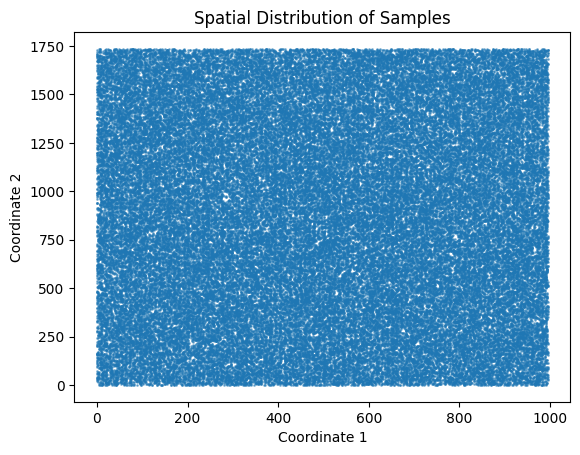

In [12]:
import matplotlib.pyplot as plt

# Extract the two coordinate dimensions
x = dataset['coord'][:, 0]
y = dataset['coord'][:, 1]

# Create a scatter plot
plt.scatter(x, y, s=1, alpha=0.5)  # Adjust `s` for marker size and `alpha` for transparency
plt.xlabel('Coordinate 1')
plt.ylabel('Coordinate 2')
plt.title('Spatial Distribution of Samples')
plt.show()

In [13]:
print(dataset['time'].min().values)
print(dataset['time'].max().values)

2018-08-01T01:00:00.000000000
2021-12-31T23:00:00.000000000


In [14]:
print(dataset['coord'][:, 0].min().values, dataset['coord'][:, 0].max().values)  # Latitude
print(dataset['coord'][:, 1].min().values, dataset['coord'][:, 1].max().values)  # Longitude

0 995
0 1735


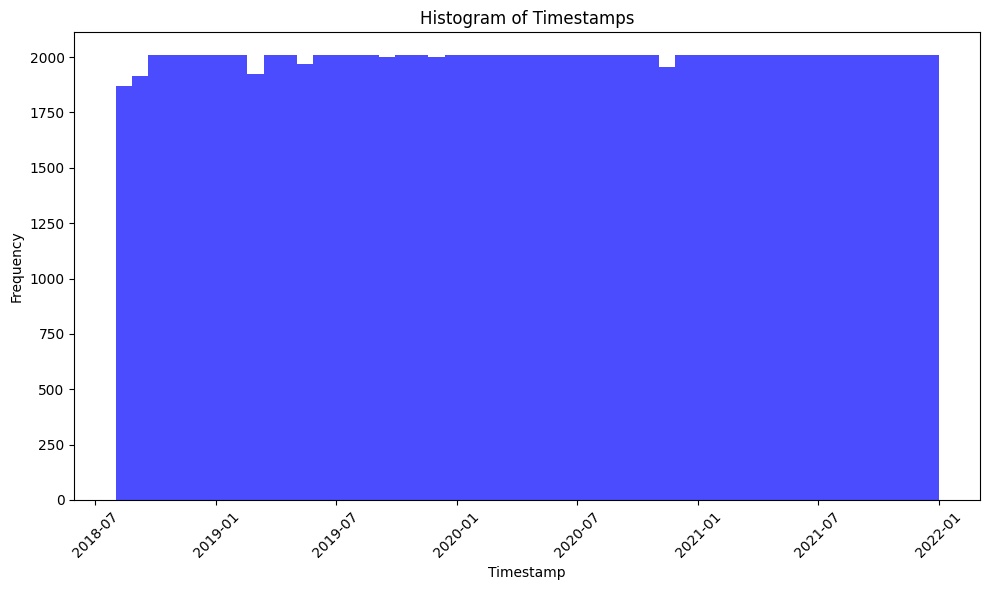

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert the 'time' variable to a pandas datetime series
timestamps = pd.to_datetime(dataset['time'].values)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(timestamps, bins=50, color='blue', alpha=0.7)  # Adjust bins as needed
plt.xlabel('Timestamp')
plt.ylabel('Frequency')
plt.title('Histogram of Timestamps')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

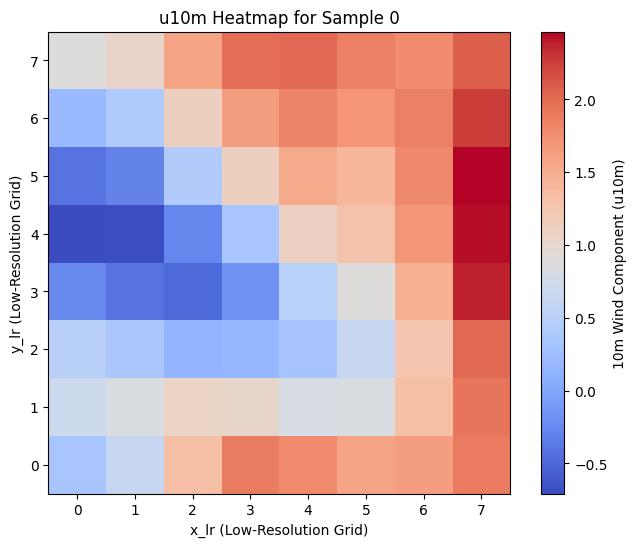

In [16]:
import matplotlib.pyplot as plt
# Select the variable 'u10m' and a specific sample (e.g., sample 0)
u10m = input_group['u10m']  # Shape: (sample, y_lr, x_lr)
sample_index = 0  # Change this to inspect other samples
u10m_sample = u10m[sample_index, :, :]

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(u10m_sample, cmap="coolwarm", origin="lower")
plt.colorbar(label="10m Wind Component (u10m)")
plt.title(f"u10m Heatmap for Sample {sample_index}")
plt.xlabel("x_lr (Low-Resolution Grid)")
plt.ylabel("y_lr (Low-Resolution Grid)")
plt.show()

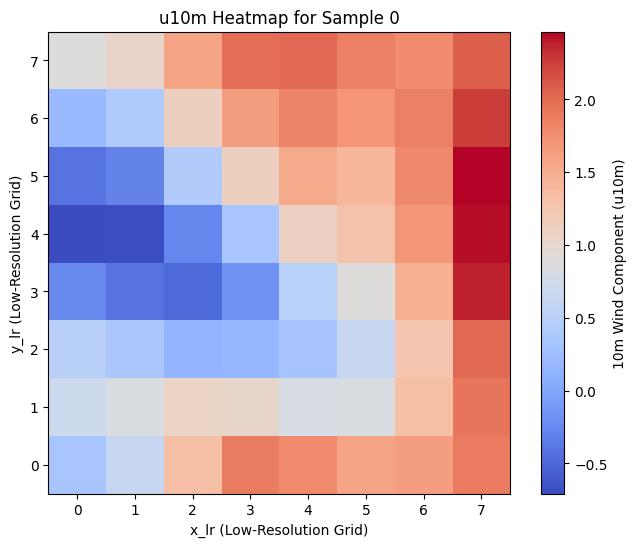

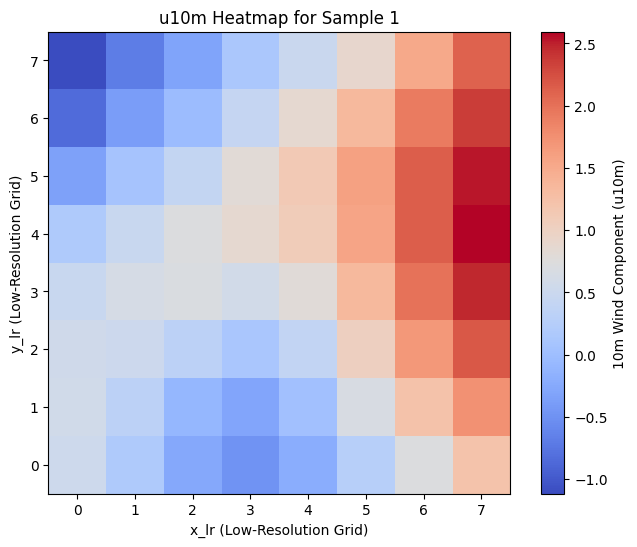

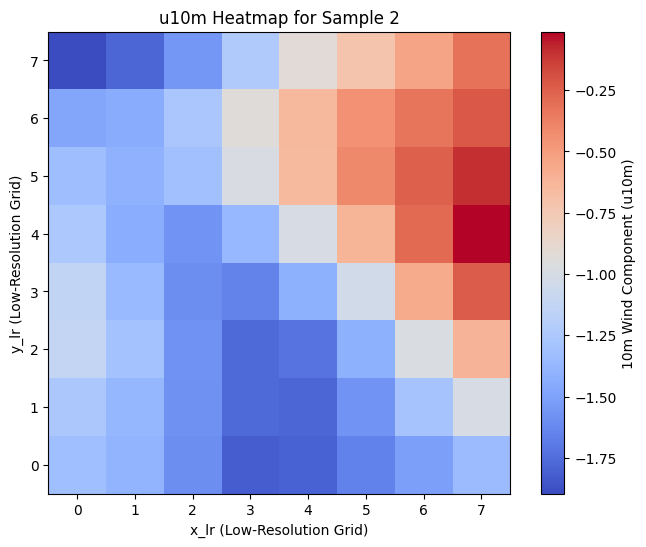

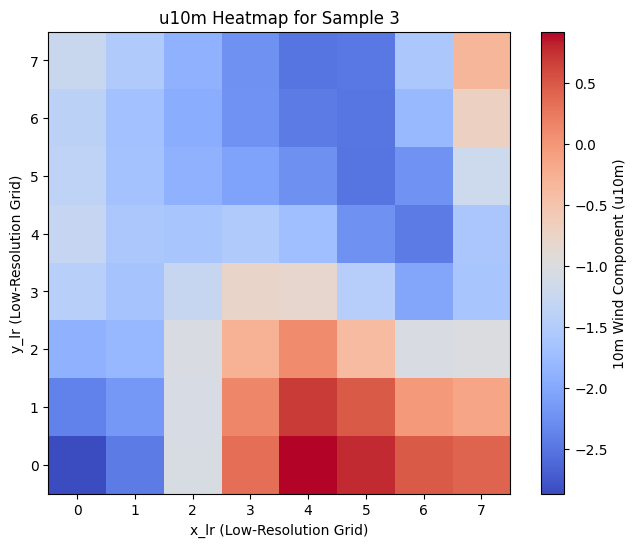

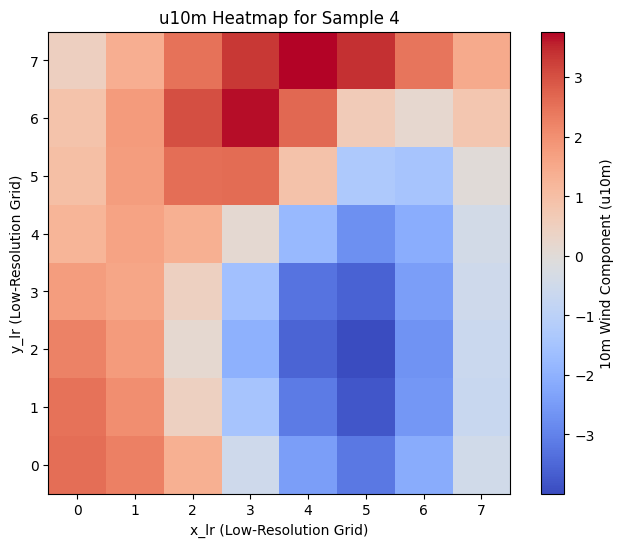

In [17]:
for sample_index in range(5):  # Inspect the first 5 samples
    u10m_sample = u10m[sample_index, :, :]
    plt.figure(figsize=(8, 6))
    plt.imshow(u10m_sample, cmap="coolwarm", origin="lower")
    plt.colorbar(label="10m Wind Component (u10m)")
    plt.title(f"u10m Heatmap for Sample {sample_index}")
    plt.xlabel("x_lr (Low-Resolution Grid)")
    plt.ylabel("y_lr (Low-Resolution Grid)")
    plt.show()

### Understanding the `u10m` Variable

#### Each Sample
- Each sample of `u10m` is an **8x8 matrix** (low-resolution grid).
- This matrix represents the **10-meter wind component** (`u10m`) over a spatial area.

#### Associated Metadata
- **Timestamp**:
  - Each sample has a corresponding timestamp stored in the `time` variable at the top level of the dataset.
- **Latitude and Longitude**:
  - Each sample has a pair of latitude and longitude coordinates stored in the `coord` variable at the top level of the dataset.
  - These coordinates likely represent the center or reference point of the 8x8 grid.

#### Dimensions
- **`sample`**:
  - Represents the number of samples (100,000 in your dataset).
- **`y_lr` and `x_lr`**:
  - Represent the 8x8 grid dimensions for each sample.

#### Summary
- Each sample of `u10m` is an **8x8 matrix** representing the 10-meter wind component over a spatial grid.
- Each sample is associated with:
  - A **timestamp** (from the `time` variable).
  - A **latitude and longitude coordinate** (from the `coord` variable).

This structure allows you to analyze the spatial patterns of `u10m` for each sample and relate them to their corresponding time and location. Let me know if you'd like to explore this further or visualize the data!

In [18]:
print(dataset['time'].min().values)
print(dataset['time'].max().values)

2018-08-01T01:00:00.000000000
2021-12-31T23:00:00.000000000


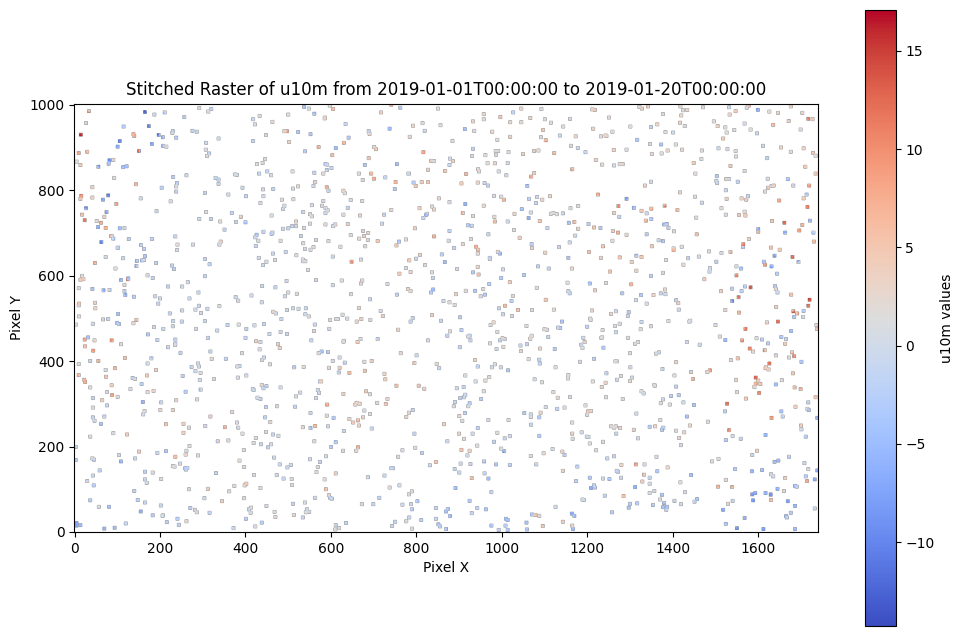

In [19]:
import numpy as np
# Define the variable and time range
variable = "u10m"  # Variable of interest
begin = np.datetime64("2019-01-01T00:00:00")  # Start time
end = np.datetime64("2019-01-20T00:00:00")    # End time

# begin = np.datetime64("2018-08-01T01:00:00.000000000")  # Start time
# end = np.datetime64("2021-12-31T23:00:00.000000000")    # End time

# Filter samples by time range
time_mask = (dataset['time'] >= begin) & (dataset['time'] <= end)
filtered_samples = np.where(time_mask)[0]  # Get indices of samples in the time range

# Extract the variable and pixel coordinates for the filtered samples
filtered_data = input_group[variable][filtered_samples, :, :]  # Shape: (num_samples, 8, 8)
coords = dataset['coord'][filtered_samples, :].values  # Shape: (num_samples, 2)

# Determine the size of the raster matrix
x_max = coords[:, 1].max() + 8  # Add 8 to account for the 8x8 grid
y_max = coords[:, 0].max() + 8  # Add 8 to account for the 8x8 grid
raster = np.full((y_max, x_max), np.nan)  # Initialize with NaN

# Insert 8x8 data into the raster
for i, (y, x) in enumerate(coords):
    raster[y:y+8, x:x+8] = filtered_data[i, :, :]

# Display the raster
plt.figure(figsize=(12, 8))
plt.imshow(raster, cmap="coolwarm", origin="lower")
plt.colorbar(label=f"{variable} values")
plt.title(f"Stitched Raster of {variable} from {begin} to {end}")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.show()


3. **Normalize the Data**:
   - Apply normalization to input and output variables.
   - Example:
     ```python
     temperature = dataset["temperature_2m"]
     normalized_temperature = (temperature - temperature.min()) / (temperature.max() - temperature.min())
     ```

4. **Split into Features and Targets**:
   - Separate input variables (features) and output variables (targets).
   - Example:
     ```python
     inputs = dataset[["temperature_2m", "pressure_surface", "wind_u_10m", "wind_v_10m"]]
     targets = dataset["temperature_2m_future"]
     ```

5. **Prepare for Training**:
   - Convert the data into a format suitable for machine learning models, such as NumPy arrays or PyTorch tensors.
   - Example:
     ```python
     inputs_array = inputs.to_array().values
     targets_array = targets.values
     ```


# 3. Setting Up the Environment

## 3.1 Using the Provided Docker Container

The repository includes a pre-configured Docker setup to simplify the installation process and ensure compatibility across different systems. Docker allows you to run the code in an isolated environment with all dependencies pre-installed.

### Steps to Build and Run the Docker Container:
1. **Build the Docker Image**:
   - Use the provided script to build the Docker image.
   - Command:
     ```bash
     bash scripts/build_docker.sh
     ```
   - This script uses the  located in the  directory to create an image with all necessary dependencies.

2. **Run the Docker Container**:
   - Use the provided script to start the container.
   - Command:
     ```bash
     bash scripts/run_docker.sh
     ```
   - This script runs the container in interactive mode and mounts the repository directory inside the container.

3. **Verify the Container**:
   - Once inside the container, check the Python version and installed packages.
   - Commands:
     ```bash
     python3 --version
     pip list
     ```

---

## 3.2 Installing Dependencies and Verifying the Setup

The Docker container includes most of the required dependencies. However, you may need to install additional Python packages or verify the setup.

### Steps to Install Dependencies:
1. **Install Python Packages**:
   - Inside the container, install the required Python packages using `pip`.
   - Command:
     ```bash
     pip install -r requirements_docker.txt
     ```

2. **Install the  Package**:
   - The repository includes a local Python package named . Install it in editable mode.
   - Command:
     ```bash
     pip install --no-cache-dir -e .
     ```

3. **Verify the Installation**:
   - Check if the  package is installed correctly.
   - Command:
     ```bash
     python3 -c "import physicsnemo; print('PhysicsNemo installed successfully!')"
     ```

---

## 3.3 Running a Jupyter Notebook Inside the Container

Jupyter Notebook is a powerful tool for interactive coding and visualization. The Docker container is pre-configured to run a Jupyter Notebook server.

### Steps to Start the Jupyter Notebook Server:
1. **Start the Server**:
   - Inside the container, run the following command:
     ```bash
     jupyter notebook --ip=0.0.0.0 --no-browser --allow-root
     ```
   - This starts the Jupyter Notebook server and makes it accessible from your host machine.

2. **Access the Notebook**:
   - Copy the URL displayed in the terminal (it includes a token for authentication).
   - Open the URL in your web browser to access the Jupyter Notebook interface.

3. **Verify the Setup**:
   - Create a new notebook and run a simple Python command to verify the environment.
   - Example:
     ```python
     import physicsnemo
     print("Environment is ready!")
     ```

---

## 3.4 Troubleshooting Tips

If you encounter any issues during setup, here are some common solutions:
1. **Docker Build Errors**:
   - Ensure Docker is installed and running on your machine.
   - Check the  for any syntax errors or missing dependencies.

2. **Missing Python Packages**:
   - Install the missing packages using `pip` inside the container.

3. **Jupyter Notebook Access Issues**:
   - Ensure the container's port (default: 8888) is exposed and accessible from your host machine.
   - Use the correct token from the terminal output to authenticate.



# 4. Exploring the Repository

## 4.1 Key Components of the `physicsnemo` Repository

The `physicsnemo` repository is designed to facilitate weather forecasting using machine learning models. It contains several key components that work together to preprocess data, train models, and evaluate their performance.

### Key Directories and Files:
1. **`examples/weather/cordiff`**:
   - This directory contains the implementation of the CorrDiff model, including its architecture, training scripts, and utilities.
   - Key files:
     - `train.py`: Script to train the CorrDiff model.
     - `README.md`: Documentation. It is very usefull in case of training on custom dataset.

2. **`examples/weather/cordiff/conf`**:
   - This directory contains configuration files for training the CorrDiff model.
   - Key files:
     - `config_training_hrrr_mini_regression.yaml`: Configuration for training the regression model.
     - `config_training_hrrr_mini_diffusion.yaml`: Configuration for training the diffusion model.

3. **`data/`**:
   - This directory is used to store datasets, such as `hrrr_mini_train.nc` and `hrrr_mini_test.nc`.

4. **`notebooks/`**:
   - Contains Jupyter Notebooks for tutorials and experiments.

5. **`scripts/`**:
   - Contains helper scripts for building and running the Docker container, as well as other utilities.

6. **`requirements_docker.txt`**:
   - Lists the Python dependencies required to run the repository.

---

## 4.2 Overview of the CorrDiff Training Pipeline

The CorrDiff training pipeline is designed to train machine learning models for weather forecasting. It consists of the following steps:

### 1. **Data Loading and Preprocessing**:
   - The pipeline begins by loading the HRRR-Mini dataset (`hrrr_mini_train.nc`).
   - Data is normalized and split into input variables (features) and output variables (targets).
   - Static variables (e.g., elevation, land-sea mask) are also loaded to provide additional context.

### 2. **Model Initialization**:
   - The CorrDiff model is initialized based on the configuration file.
   - The model consists of two components:
     - **Regression Model**: Predicts coarse-grained weather variables.
     - **Diffusion Model**: Refines predictions to capture fine-grained details and uncertainties.

### 3. **Training**:
   - The model is trained using the training dataset.
   - Loss functions and optimization algorithms are defined in the configuration file.
   - Checkpoints are saved periodically to allow resuming training.

### 4. **Evaluation**:
   - The trained model is evaluated on the test dataset (`hrrr_mini_test.nc`).
   - Metrics such as Mean Squared Error (MSE) and correlation coefficients are used to assess performance.

### 5. **Inference**:
   - The model is used to make predictions on new data.
   - Outputs are visualized to analyze the model's performance.

---

## 4.3 Understanding the Configuration Files

The configuration files in `weather/cordiff/conf` define the parameters for training the CorrDiff model. Let’s explore the two key configuration files:

### 1. `config_training_hrrr_mini_regression.yaml`
This file is used to train the regression model, which serves as the foundation for the CorrDiff pipeline.

#### Key Sections:
#### **`data`**:
  - This section ensures the correct dataset is loaded and specifies the variables the model will predict.
  - Example:
  - ```yaml
      dataset:
      type: hrrr_mini #Specifies the dataset type. Other options: `gefs_hrrr`, `cwb`, `custom`.
      data_path: /app/data/weather_data/hrrr_mini_train.nc #Path to the training dataset file.
      stats_path: /app/data/weather_data/stats.json #Path to the statistics file containing dataset metadata (e.g., mean, standard deviation).
      output_variables: #List of target variables to predict.
      - 10u
      - 10v
    ```

- **`model`**:
  - This section defines the structure and behavior of the regression model, including its embedding type, channel configuration, and attention mechanisms.

  - Example:
    ```yaml
    model:
      name: regression
      hr_mean_conditioning: false #Boolean flag indicating whether high-resolution mean conditioning is used.
      model_args: #Additional arguments for the model architecture.
        N_grid_channels: 4 #Number of grid channels used in the model.
        embedding_type: zero #Type of embedding used in the model.
        model_channels: 64 #Number of channels in the model.
        channel_mult: #Multipliers for the number of channels at different resolutions.
        - 1
        - 2
        - 2
        attn_resolutions: #Resolutions at which attention mechanisms are applied.
        - 16
    ```

- **`training`**:
  - This section specifies the training parameters, including hyperparameters and optimization settings.
  - Example:
    ```yaml
    training:
      hp:
        training_duration: 2000000 #Total number of samples to process during training.
        total_batch_size: 8 #Total batch size across all GPUs.
        batch_size_per_gpu: 8 #Batch size per GPU
        lr: 0.0002 #Learning rate for the optimizer.
        grad_clip_threshold: 4 #Threshold for gradient clipping to prevent exploding gradients.
        lr_decay: 1 #Learning rate decay factor.
        lr_rampup: 0 #Number of samples over which the learning rate is ramped up.
        lr_decay_rate: 500000.0 #Rate at which the learning rate decays.
      perf:
        fp_optimizations: amp-bf16 #Floating-point optimizations for mixed precision training.
        dataloader_workers: 4 #Number of workers for data loading.
        songunet_checkpoint_level: 0 #Checkpoint level for the SongUNet model.
        use_gpu: true #Boolean flag indicating whether GPUs are used.
        num_gpus: -1 #Number of GPUs to use. `-1` (use all available GPUs).
      io:
        regression_checkpoint_path: null #Path to the regression model checkpoint.
        print_progress_freq: 100 #Frequency of progress updates during training.
        save_checkpoint_freq: 5000 #Frequency of saving model checkpoints.
        save_n_recent_checkpoints: -1 #Number of recent checkpoints to keep.
        validation_freq: 5000 #Frequency of validation during training.
        validation_steps: 10 #Number of validation steps.
    ```

- **`wandb`**:
  - This section configures Weights & Biases (W&B) for experiment tracking.
  - Example:
    ```yaml
    wandb:
      mode: offline #Mode for W&B logging (`offline`, `online`, `disabled`).
      results_dir: ./wandb #Directory to store W&B results.
      watch_model: false #Boolean flag indicating whether to track model parameters and gradients.
    ```

---

### 2. `config_training_hrrr_mini_diffusion.yaml`
This file is used to train the diffusion model, which refines the predictions made by the regression model.
#### Key Sections:
TODO: to be done later when I will start working on diffusion training

---

## 4.4 Summary

By exploring the repository, we now understand:
1. The key components of the `physicsnemo` repository.
2. The steps involved in the CorrDiff training pipeline.
3. The purpose and structure of the configuration files.


In [21]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.data_path="/app/data/weather_data/hrrr_mini_train.nc" \
    dataset.stats_path="/app/data/weather_data/stats.json" \
    --config-name=config_training_hrrr_mini_regression \
    --cfg job

W0722 10:36:18.212127 2028 torch/distributed/run.py:766] 
W0722 10:36:18.212127 2028 torch/distributed/run.py:766] *****************************************
W0722 10:36:18.212127 2028 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0722 10:36:18.212127 2028 torch/distributed/run.py:766] *****************************************
^C
W0722 10:36:22.197245 2028 torch/distributed/elastic/agent/server/api.py:719] Received 2 death signal, shutting down workers
W0722 10:36:22.198047 2028 torch/distributed/elastic/multiprocessing/api.py:900] Sending process 2095 closing signal SIGINT
W0722 10:36:22.198563 2028 torch/distributed/elastic/multiprocessing/api.py:900] Sending process 2096 closing signal SIGINT
W0722 10:36:22.198997 2028 torch/distributed/elastic/multiprocessing/api.py:900] Sending process 2097

# 5. Training the HRRR-Mini Regression Model

## 5.1. Overview

In this section, we will train the HRRR-Mini regression model using the `config_training_hrrr_mini_regression.yaml` configuration file. This model predicts primary weather variables based on input data and serves as the foundation for the CorrDiff forecasting pipeline.

## 5.2. Step-by-Step Walkthrough

### Step 1: Set Up the Environment

Before training the model, ensure that you have set up the environment correctly. You can use the provided Docker container to simplify the installation process.

1. **Build the Docker Image**:
   bash scripts/build_docker.sh

2. **Run the Docker Container**:
   bash scripts/run_docker.sh

3. **Verify the Setup**:
   Inside the container, check the Python version and installed packages:
   python3 --version
   pip list

### Step 2: Prepare the Configuration File

The configuration file `config_training_hrrr_mini_regression.yaml` contains all the necessary parameters for training the regression model. Ensure that the paths to the dataset and statistics files are correctly specified.

### Step 3: Start Training the Model

To train the regression model, execute the following command inside the Docker container:

```sh
cd /app && torchrun --nproc_per_node=8 \
    examples/weather/cordiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.data_path="/app/data/weather_data/hrrr_mini_train.nc" \
    dataset.stats_path="/app/data/weather_data/stats.json" \
    --config-name=config_training_hrrr_mini_regression 
```

### Step 4: Monitoring Training Progress

During training, you can monitor the progress through the console output. The training script will display information such as the current epoch, loss values, and any validation metrics defined in the configuration file.

### Step 5: Saving Checkpoints

The model checkpoints will be saved periodically based on the configuration settings. You can specify the frequency of saving checkpoints in the `training` section of the configuration file. This allows you to resume training later if needed.

## 5.3 Conclusion

By following these steps, you will successfully train the HRRR-Mini regression model using the provided configuration file. This model will serve as the basis for further experiments and improvements in weather forecasting using the CorrDiff framework. 

Feel free to explore the results and adjust the configuration parameters to optimize the model's performance.

# 6. Train the Regression on Custom Data

## 6.1 Overview

In this section, we will:
1. Investigate the custom dataset.
2. Understand its structure and contents.
3. Perform necessary preprocessing steps to prepare the data for training.
4. Train the regression model using the processed custom dataset.

---

## 6.2 Investigating the Custom Dataset

### Step 1: Unzipping the Files
- The dataset consists of multiple zip files. We will first extract these files to inspect their contents.

In [20]:
ls -lh /app/data/custom_data_1/

total 11G
-rwxrwxrwx 1 1018 1018 517M Jul 17 13:17 ERA5-20250716T095623Z-1-001.zip*
drwxrwxrwx 2 root root 4.0K Jul 22 11:40 ERA5_preprocessed/
drwxrwxrwx 3 root root 4.0K Jul 31 06:30 ERA5_wrf_combined/
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:13 WRF-20250716T095739Z-1-001.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:15 WRF-20250716T095739Z-1-002.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:14 WRF-20250716T095739Z-1-003.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:17 WRF-20250716T095739Z-1-004.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:16 WRF-20250716T095739Z-1-005.zip*
drwxrwxrwx 4 root root 4.0K Jul 17 13:30 unziped/


In [22]:
#! apt-get update && apt-get install -y unzip

In [15]:
#%%sh 
#for file in /app/data/custom_data_1/*.zip; do unzip "$file" -d /app/data/custom_data_1/unziped; done

Archive:  /app/data/custom_data_1/ERA5-20250716T095623Z-1-001.zip
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-28.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-26.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-29.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-19.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-30.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-14.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-22.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-25.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-27.nc  
  inflating: /app/data/custom_data_1/unziped/ERA5/era5_single_levels_cropped_2024-08-12.nc  
  in

### Step 2: Exploring the Extracted Files
- After unzipping, we will list the files and directories to understand the dataset structure.

In [23]:
ls -ls /app/data/custom_data_1/unziped

total 52
40 drwxrwxrwx 2 root root 36864 Jul 17 13:27 ERA5/
12 drwxrwxrwx 2 root root 12288 Jul 17 13:28 WRF/


ERA5 and WRF are widely used datasets in weather forecasting and climate modeling:

#### ERA5:

ERA5 is a global reanalysis dataset produced by the European Centre for Medium-Range Weather Forecasts (ECMWF). It provides hourly estimates of atmospheric, ocean-wave, and land-surface variables. Key features include:

- **Spatial Resolution**: Approximately 31 km globally.
- **Temporal Coverage**: From 1979 to the present.
- **Variables**: Includes temperature, pressure, wind components, humidity, and more at various pressure levels.
- **Applications**: Used for climate research, weather forecasting, and machine learning tasks.

#### WRF:

WRF (Weather Research and Forecasting) is a numerical weather prediction model developed for atmospheric research and operational forecasting. It generates high-resolution weather simulations based on initial conditions and physical models. Key features include:

- **Customizable Domains**: Users can define specific regions for simulation.
- **Variables**: Includes temperature, wind, precipitation, and other meteorological parameters.
- **Applications**: Used for regional weather forecasting, climate studies, and severe weather analysis.

#### Description of Your Data:

The unzipped folders contain:

1. **ERA5 Folder**:
    - Files like `era5_pressure_levels_cropped_2024-01-01.nc` suggest ERA5 data cropped to specific regions or variables.
    - Likely contains atmospheric variables at different pressure levels.
2. **WRF Folder**:
    - Likely contains output from WRF simulations, which may include high-resolution weather data for specific regions.

In [24]:
! du -ahx /app/data/custom_data_1/unziped --exclude=/tmp | sort -rh -T /dev/shm | head -n 20

12G	/app/data/custom_data_1/unziped
9.8G	/app/data/custom_data_1/unziped/WRF
1.3G	/app/data/custom_data_1/unziped/ERA5
108M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-03-09.nc
107M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-04-16.nc
105M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-05-02.nc
101M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-04-17.nc
101M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-03-05.nc
99M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-03-06.nc
98M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-04-15.nc
98M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-03-10.nc
95M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-04-14.nc
95M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-02-26.nc
95M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-02-13.nc
93M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-03-07.nc
93M	/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-02-29.nc
92M	/

### Step 3: Inspecting File Formats
- Identify the file formats (e.g., `.nc`, `.csv`, `.txt`) and their contents.

In [25]:
! find /app/data/custom_data_1 -type f | sed -n 's/.*\.//p' | sort | uniq

DS_Store
json
nc
zip


### Step 4: Loading the Data
- Use appropriate Python libraries to load the data based on its format.
    - For `.nc` files: `xarray` or `netCDF4`.
    - For `.csv` files: `pandas`.
    - For `.txt` files: `numpy`.

In [26]:
import xarray as xr
era5_data_path = "/app/data/custom_data_1/unziped/ERA5/era5_pressure_levels_cropped_2024-03-09.nc" 
era5_dataset = xr.open_dataset(era5_data_path)
era5_dataset

<xarray.Dataset> Size: 1MB
Dimensions:         (valid_time: 24, pressure_level: 2, latitude: 36,
                     longitude: 38)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 192B 2024-03-09 ... 2024-03-0...
  * longitude       (longitude) float64 304B 50.0 50.25 50.5 ... 59.0 59.25
  * latitude        (latitude) float64 288B 28.25 28.0 27.75 ... 20.0 19.75 19.5
  * pressure_level  (pressure_level) float64 16B 850.0 500.0
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 263kB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 263kB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 263kB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 263kB ...
Attributes:
    CDI:                     Climate Data Interface version 1.9.9rc1 (https:/...
    Conventions:             CF-1.7
    history:                 Wed Jul 09 14:11:18 2025: cdo sellonlatbox,50.0,...
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    CDO:                     Climate Data Operators version 1.9.9rc1 (https:/...

In [29]:
import xarray as xr
wrf_data_path = "/app/data/custom_data_1/unziped/WRF/wrfout_final_2024-03-09.nc" 
wrf_dataset = xr.open_dataset(wrf_data_path)
wrf_dataset

<xarray.Dataset> Size: 211MB
Dimensions:  (Time: 24, south_north: 447, west_east: 447)
Coordinates:
    XLAT     (Time, south_north, west_east) float32 19MB ...
    XLONG    (Time, south_north, west_east) float32 19MB ...
Dimensions without coordinates: Time, south_north, west_east
Data variables:
    RAINC    (Time, south_north, west_east) float32 19MB ...
    RAINNC   (Time, south_north, west_east) float32 19MB ...
    T2       (Time, south_north, west_east) float32 19MB ...
    Times    (Time) |S19 456B ...
    U10      (Time, south_north, west_east) float32 19MB ...
    V10      (Time, south_north, west_east) float32 19MB ...
    PSFC     (Time, south_north, west_east) float32 19MB ...
    Q2       (Time, south_north, west_east) float32 19MB ...
    SST      (Time, south_north, west_east) float32 19MB ...
    TSK      (Time, south_north, west_east) float32 19MB ...
Attributes: (12/139)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2024-03-08_18:00:00
    SIMULATION_START_DATE:           2024-03-08_18:00:00
    WEST-EAST_GRID_DIMENSION:        448
    SOUTH-NORTH_GRID_DIMENSION:      448
    BOTTOM-TOP_GRID_DIMENSION:       36
    ...                              ...
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    NCO:                             netCDF Operators version 4.9.1 (Homepage...
    history:                         Mon Jul  7 18:39:11 2025: ncks -A -v PSF...
    history_of_appended_files:       Mon Jul  7 18:39:11 2025: Appended file ...

In [30]:
import netCDF4 as nc

# Open the file and list all groups
with nc.Dataset(wrf_data_path) as f:
    print("Groups in the file:", list(f.groups.keys()))

Groups in the file: []


In [31]:
import netCDF4 as nc

# Open the file and list all groups
with nc.Dataset(era5_data_path) as f:
    print("Groups in the file:", list(f.groups.keys()))

Groups in the file: []


The WRF dataset (`wrfout_final_2024-03-09.nc`) is structured differently from the HRRR-Mini dataset (`hrrr_mini_train.nc`). Here's an explanation of the differences and why there are no groups in the WRF file:

---

#### **1. Structure of the WRF Dataset**

The WRF dataset does not use groups. Instead, all dimensions, coordinates, and variables are stored at the top level of the NetCDF file. This is typical for WRF output files, which are designed to store simulation results in a flat structure.

#### **Key Features of the WRF Dataset**

- **Dimensions**:
    - `Time`: Represents the temporal dimension (24 time steps in this file).
    - `south_north` and `west_east`: Represent the spatial dimensions of the simulation grid (447x447 grid points).
- **Coordinates**:
    - `XLAT` and `XLONG`: Latitude and longitude values for each grid point, stored as 3D arrays (`Time, south_north, west_east`).
- **Data Variables**:
    - Examples include:
        - `RAINC` and `RAINNC`: Cumulative and non-cumulative rainfall.
        - `T2`: Temperature at 2 meters above ground level.
        - `U10` and `V10`: Wind components at 10 meters.
        - `PSFC`: Surface pressure.
        - `Q2`: Specific humidity at 2 meters.
        - `SST`: Sea surface temperature.
        - `TSK`: Skin temperature.
        - `Times`: Timestamps for each time step.

#### **Attributes**:

The file contains metadata describing the simulation, such as:

- **Simulation Details**:
    - `TITLE`: Indicates the simulation source (WRF V4.6.0 model).
    - `START_DATE`: Start date of the simulation.
    - `DX` and `DY`: Grid spacing (2 km in this case).
    - `MAP_PROJ`: Projection type (Lambert Conformal).
- **Physical Options**:
    - `MP_PHYSICS`, `CU_PHYSICS`, `BL_PBL_PHYSICS`: Physics schemes used in the simulation.
- **Geographical Information**:
    - `CEN_LAT`, `CEN_LON`: Center latitude and longitude of the simulation domain.
    - `TRUELAT1`, `TRUELAT2`: True latitudes for the projection.

---

#### **2. Why Are There No Groups?**

Unlike the HRRR-Mini dataset, which organizes data into groups (`input`, `output`, `invariant`), WRF output files typically store all variables in a flat structure. This is because:

- WRF simulations are designed to output a large number of variables for a single simulation domain, and grouping is not necessary.
- The flat structure simplifies access to simulation results, as all variables are directly accessible without needing to specify a group.

When you inspect the file using `netCDF4`, the `list(f.groups.keys())` command returns an empty list because there are no groups defined in the file.

---

#### **3. How to Work with WRF Data**

Since the WRF dataset is flat, you can directly access dimensions, coordinates, and variables without needing to load groups. Here's how you can proceed:


## 6.3 Understanding the Dataset Structure

### Step 1: Dimensions and Variables
- Investigate the dimensions and variables in the dataset.

In [32]:
# Print dimensions and variables
print("Dimensions:", wrf_dataset.dims)
print("Variables:", wrf_dataset.data_vars)

Dimensions: FrozenMappingWarningOnValuesAccess({'Time': 24, 'south_north': 447, 'west_east': 447})
Variables: Data variables:
    RAINC    (Time, south_north, west_east) float32 19MB ...
    RAINNC   (Time, south_north, west_east) float32 19MB ...
    T2       (Time, south_north, west_east) float32 19MB ...
    Times    (Time) |S19 456B ...
    U10      (Time, south_north, west_east) float32 19MB ...
    V10      (Time, south_north, west_east) float32 19MB ...
    PSFC     (Time, south_north, west_east) float32 19MB ...
    Q2       (Time, south_north, west_east) float32 19MB ...
    SST      (Time, south_north, west_east) float32 19MB ...
    TSK      (Time, south_north, west_east) float32 19MB ...


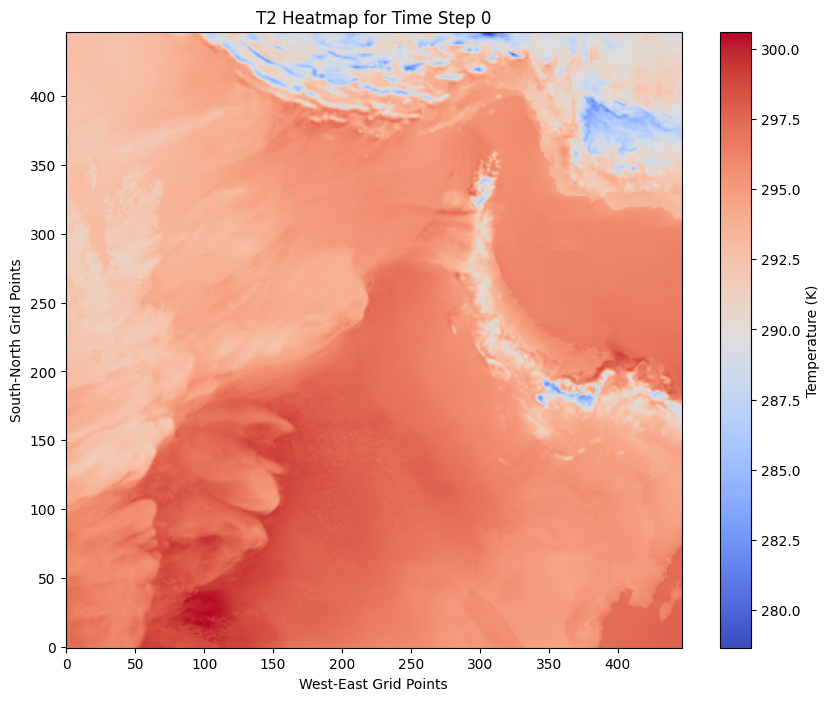

In [33]:
import matplotlib.pyplot as plt

# Select a specific time step
time_index = 0  # Change this to inspect other time steps
temperature = wrf_dataset["T2"][time_index, :, :]  # Shape: (south_north, west_east)

# Plot the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(temperature, cmap="coolwarm", origin="lower")
plt.colorbar(label="Temperature (K)")
plt.title(f"T2 Heatmap for Time Step {time_index}")
plt.xlabel("West-East Grid Points")
plt.ylabel("South-North Grid Points")
plt.show()

### Step 2: Metadata
- Check for metadata such as units, descriptions, and coordinate systems.
  
Attributes in a NetCDF dataset provide metadata about the file or specific variables. They describe the dataset's purpose, simulation details, units, coordinate systems, and other relevant information. Attributes are stored at the **global level** (file-wide) or as **variable-specific attributes**.

---

#### **How to Inspect Attributes**

To inspect attributes in your WRF dataset, you can use the following methods:

#### **1. Global Attributes**

Global attributes describe the overall dataset, such as the simulation source, start date, grid dimensions, and physical options.

In [34]:
# Print global attributes
import pprint
print("Global Attributes:")

pprint.pprint(wrf_dataset.attrs)

Global Attributes:
{'AERCU_FCT': np.float32(1.0),
 'AERCU_OPT': np.int32(0),
 'AER_ANGEXP_OPT': np.int32(1),
 'AER_ANGEXP_VAL': np.float32(1.3),
 'AER_AOD550_OPT': np.int32(1),
 'AER_AOD550_VAL': np.float32(0.12),
 'AER_ASY_OPT': np.int32(1),
 'AER_ASY_VAL': np.float32(0.9),
 'AER_OPT': np.int32(0),
 'AER_SSA_OPT': np.int32(1),
 'AER_SSA_VAL': np.float32(0.85),
 'AER_TYPE': np.int32(1),
 'AUTO_LEVELS_OPT': np.int32(2),
 'BLDT': np.float32(0.0),
 'BL_PBL_PHYSICS': np.int32(2),
 'BOTTOM-TOP_GRID_DIMENSION': np.int32(36),
 'BOTTOM-TOP_PATCH_END_STAG': np.int32(36),
 'BOTTOM-TOP_PATCH_END_UNSTAG': np.int32(35),
 'BOTTOM-TOP_PATCH_START_STAG': np.int32(1),
 'BOTTOM-TOP_PATCH_START_UNSTAG': np.int32(1),
 'BUCKET_J': np.float32(-1.0),
 'BUCKET_MM': np.float32(-1.0),
 'CEN_LAT': np.float32(23.895401),
 'CEN_LON': np.float32(54.644836),
 'CLDOVRLP': np.int32(2),
 'CUDT': np.float32(5.0),
 'CU_PHYSICS': np.int32(1),
 'DAMPCOEF': np.float32(0.2),
 'DAMP_OPT': np.int32(0),
 'DFI_OPT': np.int32(0),

---
#### **2. Variable-Specific Attributes**

Each variable may have its own attributes, such as units, descriptions, or coordinate systems.

In [35]:
# Inspect attributes for a specific variable (e.g., T2)

variable_name = "T2" # Replace with the variable you want to inspect

print(f"Attributes for {variable_name}:")

print(wrf_dataset[variable_name].attrs)

Attributes for T2:
{'FieldType': np.int32(104), 'MemoryOrder': 'XY ', 'description': 'TEMP at 2 M', 'units': 'K', 'stagger': ''}


---
#### **Why Attributes Are Important**

Attributes provide essential information for understanding and working with the dataset:

1. **Units**: Ensure proper interpretation of variable values (e.g., temperature in Kelvin, wind speed in m/s).
2. **Descriptions**: Explain the purpose or meaning of each variable.
3. **Coordinate Systems**: Specify how spatial data is organized (e.g., latitude/longitude).


## 6.4 Preprocessing the Custom Dataset

To train the regression model on our custom dataset, we need to follow these steps systematically:

---

### **Step 1: Understand the Dataset Structure**

- **Why?**
    
    Our custom dataset has a different structure compared to the HRRR-Mini dataset. HRRR-Mini uses groups (input, output, invariant), while our custom dataset has ERA5 and WRF data stored separately. We need to preprocess and combine these datasets into a unified format suitable for training.
    
- **What to do?**
    - Extract the required variables from ERA5 (`ds_input`) and WRF (`ds_output`).
    - Regrid ERA5 data to match the WRF grid.
    - Combine the regridded ERA5 data and WRF data into a single NetCDF file with groups (input, output, invariant) similar to HRRR-Mini.

---

### **Step 2: Preprocessing ERA5 Data to Match WRF Grid**

#### Objective
The goal of this step is to preprocess ERA5 data by interpolating it to the WRF grid and extracting the required variables at specific pressure levels. This ensures that the ERA5 data is compatible with the WRF grid for further processing and merging.

#### Steps Performed

1. **Input Directories**:
   - **ERA5_DIR**: `/app/data/custom_data_1/unziped/ERA5/`  
     Contains both pressure-level and single-level ERA5 NetCDF files.
   - **WRF_DIR**: `/app/data/custom_data_1/unziped/WRF/`  
     Contains WRF output files with the target grid.

2. **Output Directory**:
   - **OUT_DIR**: `/app/data/custom_data_1/ERA5_preprocessed/`  
     Preprocessed ERA5 files will be saved here.

3. **Variables Processed**:
   - **Pressure-Level Variables** (`VARIABLES`):  
     `["t", "z", "u", "v"]`  
     These variables are interpolated at the specified pressure levels: `[500, 850]` hPa.
   - **Single-Level Variables** (`SINGLE_VARS`):  
     `["u10", "v10", "d2m", "t2m", "sst", "skt", "sp", "tcwv", "tp", "q"]`  
     These variables are interpolated directly without pressure-level selection.

4. **Interpolation Method**:
   - Bicubic interpolation is used to regrid the ERA5 data to match the WRF grid. This ensures that the spatial resolution and grid structure of the ERA5 data align with the WRF data.

5. **Processing Logic**:
   - For each date in the ERA5 dataset:
     - Extract pressure-level variables (`t`, `z`, `u`, `v`) at 500 hPa and 850 hPa.
     - Extract single-level variables (`u10`, `v10`, `d2m`, etc.).
     - Interpolate all variables to the WRF grid using the latitude and longitude from the WRF file.
     - Save the interpolated variables into a new NetCDF file in the output directory.


In [36]:
#pip install scipy==1.16.0

In [37]:
import os
import xarray as xr
import numpy as np
from glob import glob
from scipy.interpolate import griddata
from scipy.interpolate import RectBivariateSpline

from utils.interp_era5_to_wrf import process_date

ERA5_DIR = "/app/data/custom_data_1/unziped/ERA5/"  # Folder with both pressure and single level files
WRF_DIR = "/app/data/custom_data_1/unziped/WRF/"
OUT_DIR = "/app/data/custom_data_1/ERA5_preprocessed/"
LEVELS = [500, 850]  # hPa
VARIABLES = ["t", "z", "u", "v"]  # From pressure level file
SINGLE_VARS = ["u10", "v10", "d2m", "t2m", "sst", "skt", "sp", "tcwv", "tp", "q"]       # From single level file
os.makedirs(OUT_DIR, exist_ok=True)

era5_files = sorted(glob(os.path.join(ERA5_DIR, "era5_pressure_levels_cropped_*.nc")))
date_list = [os.path.basename(f).replace("era5_pressure_levels_cropped_", "").replace(".nc", "") for f in era5_files]

for date in date_list:
    process_date(date, ERA5_DIR, WRF_DIR, OUT_DIR, VARIABLES, LEVELS, SINGLE_VARS)



 Processing date: 2024-01-01
 Skipping.

 Processing date: 2024-01-02
 Skipping.

 Processing date: 2024-01-03
 Skipping.

 Processing date: 2024-01-04
 Skipping.

 Processing date: 2024-01-05
 Skipping.

 Processing date: 2024-01-06
 Skipping.

 Processing date: 2024-01-07
 Skipping.

 Processing date: 2024-01-08
 Skipping.

 Processing date: 2024-01-09
 Skipping.

 Processing date: 2024-01-10
 Skipping.

 Processing date: 2024-01-11
 Skipping.

 Processing date: 2024-01-12
 Skipping.

 Processing date: 2024-01-13
 Skipping.

 Processing date: 2024-01-14
 Skipping.

 Processing date: 2024-01-15
 Skipping.

 Processing date: 2024-01-16
 Skipping.

 Processing date: 2024-01-17
 Skipping.

 Processing date: 2024-01-18
 Skipping.

 Processing date: 2024-01-19
 Skipping.

 Processing date: 2024-01-20
 Skipping.

 Processing date: 2024-01-21
 Skipping.

 Processing date: 2024-01-22
 Skipping.

 Processing date: 2024-01-23
 Skipping.

 Processing date: 2024-01-24
 Skipping.

 Processing dat

In [5]:
ls /app/data/custom_data_1/unziped/WRF/invariants_wrf.nc

ls: cannot access '/app/data/custom_data_1/unziped/WRF/invariants_wrf.nc': No such file or directory


### **Step 3: Merging Preprocessed ERA5 Data with WRF Data**

#### Objective
The goal of this step is to merge the preprocessed ERA5 data (interpolated to the WRF grid) with the WRF output data into a unified NetCDF format. This format is structured into groups (`input`, `output`, `invariant`) for further use in training or analysis.

#### Steps Performed

1. **Input Directories**:
   - **ERA5_DIR**: `/app/data/custom_data_1/ERA5_preprocessed/`  
     Contains preprocessed ERA5 files with variables interpolated to the WRF grid.
   - **WRF_DIR**: `/app/data/custom_data_1/unziped/WRF/`  
     Contains WRF output files with variables on the target grid.

2. **Output Directory**:
   - **OUT_DIR**: `/app/data/custom_data_1/ERA5_wrf_combined/`  
     The merged NetCDF files will be saved here.

3. **Merging Logic**:
   - For each preprocessed ERA5 file:
     - Match it with the corresponding WRF file based on the date in the filename.
     - Extract the required variables from both datasets:
       - **ERA5 Variables (`input`)**:
         - Pressure-level variables: `t_850`, `t_500`, `z_850`, `z_500`, `u_850`, `u_500`, `v_850`, `v_500`
         - Single-level variables: `u10`, `v10`, `t2m`, `d2m`, `skt`, `sst`, `sp`, `tcwv`, `tp`
       - **WRF Variables (`output`)**:
         - `T2`, `U10`, `V10`, `rain_rate`, `SST`, `TSK`, `Q2`, `PSFC`
       - **WRF Invariant Variables (`invariant`)** (if available):
         - `XLAT`, `XLONG`, `elev_mean`, `lsm_mean`, `land_use`
     - Compute the rain rate (`rain_rate`) from WRF variables `RAINC` and `RAINNC`.
     - Save the merged data into a NetCDF file with groups:
       - `input`: Contains ERA5 variables.
       - `output`: Contains WRF variables.
       - `invariant`: Contains WRF invariant variables.

In [4]:
import os
import glob
import json
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from utils.merge import merge_files

ERA5_DIR = "/app/data/custom_data_1/ERA5_preprocessed/"
WRF_DIR = "/app/data/custom_data_1/unziped/WRF/"
OUT_DIR = "/app/data/custom_data_1/ERA5_wrf_combined/"

os.makedirs(OUT_DIR, exist_ok=True)

merge_files(ERA5_DIR, WRF_DIR, OUT_DIR)

Merging files from /app/data/custom_data_1/ERA5_preprocessed/ and /app/data/custom_data_1/unziped/WRF/ into /app/data/custom_data_1/ERA5_wrf_combined/
Merging interpolated_era5_2024-01-26.nc + wrfout_final_2024-01-26.nc
Processing 2024-01-26...
ERA5 variables: ['t_500', 't_850', 'z_500', 'z_850', 'u_500', 'u_850', 'v_500', 'v_850', 'u10', 'v10', 'd2m', 't2m', 'sst', 'skt', 'sp', 'tcwv', 'tp', 'q']
WRF variables: ['RAINC', 'RAINNC', 'T2', 'Times', 'U10', 'V10', 'PSFC', 'Q2', 'SST', 'TSK', 'rain_rate']
Saved: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-26.nc
Merging interpolated_era5_2024-01-29.nc + wrfout_final_2024-01-29.nc
Processing 2024-01-29...
ERA5 variables: ['t_500', 't_850', 'z_500', 'z_850', 'u_500', 'u_850', 'v_500', 'v_850', 'u10', 'v10', 'd2m', 't2m', 'sst', 'skt', 'sp', 'tcwv', 'tp', 'q']
WRF variables: ['RAINC', 'RAINNC', 'T2', 'Times', 'U10', 'V10', 'PSFC', 'Q2', 'SST', 'TSK', 'rain_rate']
Saved: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_co

### **Step 4: Computing Dataset Statistics**

#### Objective
The purpose of this step is to compute statistical summaries (mean and standard deviation) for all variables in the merged dataset. These statistics are essential for normalizing the data during training or analysis.

#### Steps Performed

1. **Input Directory**:
   - **OUT_DIR**: `/app/data/custom_data_1/ERA5_wrf_combined/`  
     Contains the merged NetCDF files with groups (`input`, `output`, `invariant`).

2. **Output File**:
   - **JSON_OUT**: `/app/data/custom_data_1/ERA5_wrf_combined/uae_stats.json`  
     The computed statistics will be saved in this JSON file.

3. **Invariant Dataset**:
   - **INVARIANT_FILE**: Not used in this step (`None`).  
     If available, invariant variables (e.g., `XLAT`, `XLONG`, `elev_mean`, etc.) can also be included in the statistics.

4. **Statistics Computed**:
   - For each variable in the `input` and `output` groups:
     - **Mean**: The average value of the variable across all samples.
     - **Standard Deviation (std)**: The spread of the variable's values.
   - For invariant variables (if provided):
     - Compute mean and standard deviation for the spatial grid.

In [6]:
from utils.merge import compute_dataset_stats

JSON_OUT = os.path.join(OUT_DIR, "uae_stats.json")
INVARIANT_FILE = None #os.path.join(WRF_DIR, "invariants_wrf.nc")
invariant_ds = None #xr.open_dataset(INVARIANT_FILE)[["XLAT", "XLONG", "elev_mean", "lsm_mean", "land_use"]]

compute_dataset_stats(OUT_DIR, JSON_OUT, invariant_ds=invariant_ds)

Saved full variable stats (input, output, invariant) to /app/data/custom_data_1/ERA5_wrf_combined/uae_stats.json


/app/notebooks/tutorials/cordiff/utils/merge.py:118: RuntimeWarning: invalid value encountered in scalar divide
  mean = v["sum"] / v["count"]
/app/notebooks/tutorials/cordiff/utils/merge.py:119: RuntimeWarning: invalid value encountered in scalar divide
  std = np.sqrt(v["sumsq"] / v["count"] - mean ** 2)


### **Step 5: Concatenating All Merged Files into a Single Dataset**

#### Objective
This step combines all the individual NetCDF files in the `OUT_DIR` into a single `.nc` file. The resulting file contains all `input`, `output`, and `invariant` variables from the merged datasets, structured for efficient use in training or analysis. Additionally, the `time` and `coord` variables are added to the root group, and the `sample` dimension is properly handled.

---

#### Steps Performed

1. **Input Directory**:
   - **OUT_DIR**: `/app/data/custom_data_1/ERA5_wrf_combined/`  
     Contains the individual NetCDF files with groups (`input`, `output`, `invariant`).

2. **Output File**:
   - **OUTPUT_FILE**: `/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc`  
     The concatenated dataset will be saved in this file.

3. **Concatenation Logic**:
   - **File Filtering**:
     - All `.nc` files in the `OUT_DIR` are included, except the output file (`custom_concat_train.nc`) if it already exists.
   - **Group Extraction**:
     - For each file, the `input` and `output` groups are extracted and added to separate lists.
     - The `invariant` group is optional and included only if it exists.
   - **Handling `time`**:
     - The `time` variable is extracted from the filenames and expanded to match the number of samples in each file.
     - For example, if a file contains 24 samples, the corresponding timestamp is repeated 24 times.
   - **Handling `coord`**:
     - A placeholder `coord` variable is added to the root group. It is initialized with dummy values (e.g., `NaN`) and can be replaced with actual coordinates if available.
   - **Dataset Concatenation**:
     - The `input` and `output` datasets are concatenated along the `sample` dimension.
     - The `invariant` dataset is static, so only the first file's invariant data is used (if available).
   - **Dataset Writing**:
     - The concatenated datasets are written to a single NetCDF file, with variables organized into groups (`input`, `output`, `invariant`).
     - The `time` and `coord` variables are added to the root group.

In [2]:
from utils.concat import concat
import os

# Parameters
OUT_DIR = "/app/data/custom_data_1/ERA5_wrf_combined/"
OUTPUT_FILE = os.path.join(OUT_DIR, "custom_concat_train.nc")
MULTIPLE_OF = 8  # Can be set to 2, 4, 8, etc.
PAD_VALUE = 0  # Value to use for padding
end = -1

concat(OUT_DIR, OUTPUT_FILE, MULTIPLE_OF, PAD_VALUE, end)

Found 91 files to concatenate in /app/data/custom_data_1/ERA5_wrf_combined/.
Processing file: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-26.nc


/app/notebooks/tutorials/cordiff/utils/concat.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_y = ((ds.dims[dim_y] + (multiple_of - 1)) // multiple_of) * multiple_of
/app/notebooks/tutorials/cordiff/utils/concat.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_x = ((ds.dims[dim_x] + (multiple_of - 1)) // multiple_of) * multiple_of
/app/notebooks/tutorials/cordiff/utils/concat.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dim

No invariant group found in /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-26.nc, skipping invariant.
Processing file: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-29.nc


/app/notebooks/tutorials/cordiff/utils/concat.py:36: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_samples = input_ds.dims["sample"]
/app/notebooks/tutorials/cordiff/utils/concat.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_y = ((ds.dims[dim_y] + (multiple_of - 1)) // multiple_of) * multiple_of
/app/notebooks/tutorials/cordiff/utils/concat.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `D

No invariant group found in /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-29.nc, skipping invariant.
Processing file: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-02-04.nc


...

No invariant group found in /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-05-29.nc, skipping invariant.
Concatenating input datasets...


/app/notebooks/tutorials/cordiff/utils/concat.py:36: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_samples = input_ds.dims["sample"]


Concatenating output datasets...
No invariant datasets found.
Writing combined dataset to /app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train_2.nc...


/app/notebooks/tutorials/cordiff/utils/concat.py:49: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ncfile.createDimension("sample", size=combined_input.dims["sample"])
/app/notebooks/tutorials/cordiff/utils/concat.py:60: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  coord_var[:, :] = np.full((combined_input.dims["sample"], 2), 1)  # Replace with actual coordinates if available
/app/notebooks/tutorials/cordiff/utils/concat.py:73: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`

Combined dataset saved to /app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train_2.nc


In [32]:
# import os
# import xarray as xr
# from netCDF4 import Dataset
# import numpy as np
# from datetime import timedelta, datetime

# # Parameters
# OUT_DIR = "/app/data/custom_data_1/ERA5_wrf_combined/"
# OUTPUT_FILE = os.path.join(OUT_DIR, "custom_concat_train.nc")
# MULTIPLE_OF = 8  # Can be set to 2, 4, 8, etc.
# PAD_VALUE = 0  # Value to use for padding

# # Function to pad dimensions to the nearest multiple
# def pad_to_multiple_of(ds, dim_y, dim_x, multiple_of, pad_value):
#     new_y = ((ds.dims[dim_y] + (multiple_of - 1)) // multiple_of) * multiple_of
#     new_x = ((ds.dims[dim_x] + (multiple_of - 1)) // multiple_of) * multiple_of
#     pad_y = new_y - ds.dims[dim_y]
#     pad_x = new_x - ds.dims[dim_x]
#     return ds.pad({dim_y: (0, pad_y), dim_x: (0, pad_x)}, constant_values=pad_value)

# # Function to process a single file
# def process_file(file, multiple_of, pad_value):
#     print(f"Processing file: {file}")
#     input_ds = xr.open_dataset(file, group="input")
#     output_ds = xr.open_dataset(file, group="output")
    
#     # Pad input and output datasets
#     input_ds = pad_to_multiple_of(input_ds, "y_lr", "x_lr", multiple_of, pad_value)
#     output_ds = pad_to_multiple_of(output_ds, "y_hr", "x_hr", multiple_of, pad_value)
    
#     # Check for invariant group
#     try:
#         invariant_ds = xr.open_dataset(file, group="invariant")
#     except Exception:
#         print(f"No invariant group found in {file}, skipping invariant.")
#         invariant_ds = None
    
#     # Extract the date from the filename
#     date_str = os.path.basename(file).split("_")[-1].replace(".nc", "")
#     base_date = np.datetime64(date_str)
#     num_samples = input_ds.dims["sample"]
    
#     # Generate time values for the file
#     time_step = timedelta(hours=24 / num_samples)  # Time step based on num_samples
#     time_values = [base_date + np.timedelta64(int(i * time_step.total_seconds()), 's') for i in range(num_samples)]
    
#     return input_ds, output_ds, invariant_ds, time_values

# # Function to write the combined dataset to a NetCDF file
# def write_combined_dataset(output_file, combined_input, combined_output, combined_invariant, time_array):
#     print(f"Writing combined dataset to {output_file}...")
#     with Dataset(output_file, "w", format="NETCDF4") as ncfile:
#         # Create dimensions
#         ncfile.createDimension("sample", size=combined_input.dims["sample"])
#         ncfile.createDimension("coord", size=2)  # Assuming coord has 2 dimensions (latitude, longitude)

#         # Add time variable
#         time_var = ncfile.createVariable("time", "f8", ("sample",))
#         time_var[:] = time_array.astype("datetime64[s]").astype(float)  # Convert to seconds since epoch
#         time_var.units = "seconds since 1970-01-01 00:00:00"
#         time_var.calendar = "standard"

#         # Add coord variable (dummy values for now)
#         coord_var = ncfile.createVariable("coord", "f4", ("sample", "coord"))
#         coord_var[:, :] = np.full((combined_input.dims["sample"], 2), 1)  # Replace with actual coordinates if available

#         # Create groups
#         input_group = ncfile.createGroup("input")
#         output_group = ncfile.createGroup("output")
#         invariant_group = ncfile.createGroup("invariant") if combined_invariant is not None else None

#         # Add input variables
#         for var in combined_input.data_vars:
#             data = combined_input[var].values
#             dims = combined_input[var].dims
#             for dim in dims:
#                 if dim not in input_group.dimensions:
#                     input_group.createDimension(dim, size=combined_input.dims[dim])
#             input_group.createVariable(var, "f4", dims)[:] = data

#         # Add output variables
#         for var in combined_output.data_vars:
#             data = combined_output[var].values
#             dims = combined_output[var].dims
#             for dim in dims:
#                 if dim not in output_group.dimensions:
#                     output_group.createDimension(dim, size=combined_output.dims[dim])
#             output_group.createVariable(var, "f4", dims)[:] = data

#         # Add invariant variables if they exist
#         if combined_invariant is not None:
#             for var in combined_invariant.data_vars:
#                 data = combined_invariant[var].values
#                 dims = combined_invariant[var].dims
#                 for dim in dims:
#                     if dim not in invariant_group.dimensions:
#                         invariant_group.createDimension(dim, size=combined_invariant.dims[dim])
#                 invariant_group.createVariable(var, "f4", dims)[:] = data

#     print(f"Combined dataset saved to {output_file}")

# # Main function to process and combine all files
# def main():
#     # Get a list of all NetCDF files in the output directory except the output file
#     file_list = sorted([os.path.join(OUT_DIR, f) for f in os.listdir(OUT_DIR) if (f.endswith(".nc")
#                                                                                  and f != os.path.basename(OUTPUT_FILE))])
#     print(f"Found {len(file_list)} files to concatenate in {OUT_DIR}.")

#     # Initialize lists to store datasets for each group
#     input_datasets = []
#     output_datasets = []
#     invariant_datasets = []
#     time_values = []

#     # Process each file
#     for file in file_list[:5]:  # Debug with only 5 files
#         try:
#             input_ds, output_ds, invariant_ds, file_time_values = process_file(file, MULTIPLE_OF, PAD_VALUE)
#             input_datasets.append(input_ds)
#             output_datasets.append(output_ds)
#             if invariant_ds is not None:
#                 invariant_datasets.append(invariant_ds)
#             time_values.extend(file_time_values)
#         except Exception as e:
#             print(f"Skipped file {file} due to error: {e}")

#     # Concatenate datasets for each group
#     print("Concatenating input datasets...")
#     combined_input = xr.concat(input_datasets, dim="sample")
#     print("Concatenating output datasets...")
#     combined_output = xr.concat(output_datasets, dim="sample")

#     # Combine invariant datasets if they exist
#     if invariant_datasets:
#         print("Combining invariant datasets...")
#         combined_invariant = xr.concat(invariant_datasets, dim="sample")
#     else:
#         print("No invariant datasets found.")
#         combined_invariant = None

#     # Convert time values to a NumPy array
#     time_array = np.array(time_values)

#     # Write the combined dataset
#     write_combined_dataset(OUTPUT_FILE, combined_input, combined_output, combined_invariant, time_array)


# main()

Found 91 files to concatenate in /app/data/custom_data_1/ERA5_wrf_combined/.
Processing file: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-26.nc


/tmp/ipykernel_10542/2994662983.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_y = ((ds.dims[dim_y] + (multiple_of - 1)) // multiple_of) * multiple_of
/tmp/ipykernel_10542/2994662983.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_x = ((ds.dims[dim_x] + (multiple_of - 1)) // multiple_of) * multiple_of
/tmp/ipykernel_10542/2994662983.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Datas

No invariant group found in /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-26.nc, skipping invariant.
Processing file: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-29.nc


/tmp/ipykernel_10542/2994662983.py:41: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_samples = input_ds.dims["sample"]
/tmp/ipykernel_10542/2994662983.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_y = ((ds.dims[dim_y] + (multiple_of - 1)) // multiple_of) * multiple_of
/tmp/ipykernel_10542/2994662983.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_x = ((ds.dims[dim_x] 

No invariant group found in /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-29.nc, skipping invariant.
Processing file: /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-02-04.nc


...

No invariant group found in /app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-02-06.nc, skipping invariant.
Concatenating input datasets...


/tmp/ipykernel_10542/2994662983.py:41: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_samples = input_ds.dims["sample"]


Concatenating output datasets...
No invariant datasets found.
Writing combined dataset to /app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc...


/tmp/ipykernel_10542/2994662983.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ncfile.createDimension("sample", size=combined_input.dims["sample"])
/tmp/ipykernel_10542/2994662983.py:65: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  coord_var[:, :] = np.full((combined_input.dims["sample"], 2), 1)  # Replace with actual coordinates if available
/tmp/ipykernel_10542/2994662983.py:78: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names

Combined dataset saved to /app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc


#### Inspect non concatenated data

In [39]:
import xarray as xr

file_path = "/app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-26.nc"

# Open the file and list groups
with xr.open_dataset(file_path) as ds:
    print("Variables in the root group:", list(ds.data_vars))
    print("Dimensions in the root group:", list(ds.dims))

# Check for groups
from netCDF4 import Dataset

with Dataset(file_path, "r") as nc:
    print("Groups in the file:", list(nc.groups.keys()))

# Open input group list groups vars and dims
with xr.open_dataset(file_path, group="input") as ds:
    print("Variables in the input group:", list(ds.data_vars))
    print("Dimensions in the input group:", list(ds.dims))

# Open output group list groups vars and dims
with xr.open_dataset(file_path, group="output") as ds:
    print("Variables in the output group:", list(ds.data_vars))
    print("Dimensions in the output group:", list(ds.dims))

Variables in the root group: []
Dimensions in the root group: []
Groups in the file: ['input', 'output']
Variables in the input group: ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sst', 'sp', 'tcwv', 'tp']
Dimensions in the input group: ['sample', 'y_lr', 'x_lr']
Variables in the output group: ['T2', 'U10', 'V10', 'rain_rate', 'SST', 'TSK', 'Q2', 'PSFC']
Dimensions in the output group: ['sample', 'y_hr', 'x_hr']


In [3]:
import xarray as xr
import numpy as np

file_path = "/app/data/custom_data_1/ERA5_wrf_combined/inp_out_combined_2024-01-26.nc"

# Check for NaN values in input and output groups
with xr.open_dataset(file_path, group="input") as input_ds:
    print("NaN values in input variables:")
    for var in input_ds.data_vars:
        print(f"{var}: {np.isnan(input_ds[var].values).sum()} NaNs")

with xr.open_dataset(file_path, group="output") as output_ds:
    print("NaN values in output variables:")
    for var in output_ds.data_vars:
        print(f"{var}: {np.isnan(output_ds[var].values).sum()} NaNs")

NaN values in input variables:
t_850: 0 NaNs
t_500: 0 NaNs
z_850: 0 NaNs
z_500: 0 NaNs
u_850: 0 NaNs
u_500: 0 NaNs
v_850: 0 NaNs
v_500: 0 NaNs
u10: 0 NaNs
v10: 0 NaNs
t2m: 0 NaNs
d2m: 0 NaNs
skt: 0 NaNs
sst: 4795416 NaNs
sp: 0 NaNs
tcwv: 0 NaNs
tp: 0 NaNs
NaN values in output variables:
T2: 0 NaNs
U10: 0 NaNs
V10: 0 NaNs
rain_rate: 0 NaNs
SST: 0 NaNs
TSK: 0 NaNs
Q2: 0 NaNs
PSFC: 0 NaNs


#### Inspect concatenated data

In [4]:
import xarray as xr

file_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"

# Open the file and list groups
with xr.open_dataset(file_path) as ds:
    print("Variables in the root group:", list(ds.data_vars))
    print("Dimensions in the root group:", list(ds.dims))

# Check for groups
from netCDF4 import Dataset

with Dataset(file_path, "r") as nc:
    print("Groups in the file:", list(nc.groups.keys()))

# Open input group list groups vars and dims
with xr.open_dataset(file_path, group="input") as ds:
    print("Variables in the input group:", list(ds.data_vars))
    print("Dimensions in the input group:", list(ds.dims))

# Open output group list groups vars and dims
with xr.open_dataset(file_path, group="output") as ds:
    print("Variables in the output group:", list(ds.data_vars))
    print("Dimensions in the output group:", list(ds.dims))


Variables in the root group: ['time']
Dimensions in the root group: ['sample', 'coord']
Groups in the file: ['input', 'output']
Variables in the input group: ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sst', 'sp', 'tcwv', 'tp']
Dimensions in the input group: ['sample', 'y_lr', 'x_lr']
Variables in the output group: ['T2', 'U10', 'V10', 'rain_rate', 'SST', 'TSK', 'Q2', 'PSFC']
Dimensions in the output group: ['sample', 'y_hr', 'x_hr']


In [5]:
import xarray as xr
import pandas as pd

file_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"

# Open the root group and load the time variable
with xr.open_dataset(file_path) as ds:
    time_values = ds["time"].values  # Extract time values

# Convert to pandas for easier inspection
time_series = pd.to_datetime(time_values, unit="s", origin="unix")

# Check for duplicates
duplicates = time_series[time_series.duplicated()]
if not duplicates.empty:
    print("Duplicate times found:")
    print(duplicates)
else:
    print("No duplicate times found.")

# Print unique times for verification
print("Unique times:")
print(time_series.unique())

No duplicate times found.
Unique times:
DatetimeIndex(['2024-01-26 00:00:00', '2024-01-26 01:00:00',
               '2024-01-26 02:00:00', '2024-01-26 03:00:00',
               '2024-01-26 04:00:00', '2024-01-26 05:00:00',
               '2024-01-26 06:00:00', '2024-01-26 07:00:00',
               '2024-01-26 08:00:00', '2024-01-26 09:00:00',
               ...
               '2024-05-29 14:00:00', '2024-05-29 15:00:00',
               '2024-05-29 16:00:00', '2024-05-29 17:00:00',
               '2024-05-29 18:00:00', '2024-05-29 19:00:00',
               '2024-05-29 20:00:00', '2024-05-29 21:00:00',
               '2024-05-29 22:00:00', '2024-05-29 23:00:00'],
              dtype='datetime64[ns]', length=2160, freq=None)


In [38]:
import xarray as xr
import numpy as np

file_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"

# Open the root group and inspect the coord variable
with xr.open_dataset(file_path) as ds:
    if "coord" in ds.variables:
        coord_values = ds["coord"].values  # Extract coord values
        print("Shape of coord:", coord_values.shape)
        
        # Check unique values
        unique_coords = np.unique(coord_values, axis=0)
        print(f"Number of unique coordinates: {len(unique_coords)}")
        
        # Print some examples
        print("Example coordinates:")
        print(unique_coords[:5])  # Print the first 5 unique coordinates
    else:
        print("No 'coord' variable found in the root group.")

Shape of coord: (120, 2)
Number of unique coordinates: 1
Example coordinates:
[[1. 1.]]


In [39]:
import xarray as xr

file_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"

with xr.open_dataset(file_path, group="input") as input_ds:
    print("Input dimensions:", input_ds.dims)

with xr.open_dataset(file_path, group="output") as output_ds:
    print("Output dimensions:", output_ds.dims)

Input dimensions: FrozenMappingWarningOnValuesAccess({'sample': 120, 'y_lr': 448, 'x_lr': 448})
Output dimensions: FrozenMappingWarningOnValuesAccess({'sample': 120, 'y_hr': 448, 'x_hr': 448})


In [40]:
import xarray as xr
import numpy as np

file_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"

# Check for NaN values in input and output groups
with xr.open_dataset(file_path, group="input") as input_ds:
    print("NaN values in input variables:")
    for var in input_ds.data_vars:
        print(f"\t{var}: {np.isnan(input_ds[var].values).sum()} NaNs out of {input_ds[var].values.size}")

with xr.open_dataset(file_path, group="output") as output_ds:
    print(" NaN values in output variables:")
    for var in output_ds.data_vars:
        print(f"\t{var}: {np.isnan(output_ds[var].values).sum()} NaNs")

NaN values in input variables:
	t_850: 0 NaNs out of 24084480
	t_500: 0 NaNs out of 24084480
	z_850: 0 NaNs out of 24084480
	z_500: 0 NaNs out of 24084480
	u_850: 0 NaNs out of 24084480
	u_500: 0 NaNs out of 24084480
	v_850: 0 NaNs out of 24084480
	v_500: 0 NaNs out of 24084480
	u10: 0 NaNs out of 24084480
	v10: 0 NaNs out of 24084480
	t2m: 0 NaNs out of 24084480
	d2m: 0 NaNs out of 24084480
	skt: 0 NaNs out of 24084480
	sst: 23977080 NaNs out of 24084480
	sp: 0 NaNs out of 24084480
	tcwv: 0 NaNs out of 24084480
	tp: 0 NaNs out of 24084480
 NaN values in output variables:
	T2: 0 NaNs
	U10: 0 NaNs
	V10: 0 NaNs
	rain_rate: 0 NaNs
	SST: 0 NaNs
	TSK: 0 NaNs
	Q2: 0 NaNs
	PSFC: 0 NaNs


#### Inspect Hrrr data

In [45]:
import xarray as xr

file_path = "/app/data/weather_data/hrrr_mini_train.nc"

# Open the file and list groups
with xr.open_dataset(file_path) as ds:
    print("Variables in the root group:", list(ds.data_vars))
    print("Dimensions in the root group:", list(ds.dims))

# Check for groups
from netCDF4 import Dataset

with Dataset(file_path, "r") as nc:
    print("Groups in the file:", list(nc.groups.keys()))

# Open input group list groups vars and dims
with xr.open_dataset(file_path, group="input") as ds:
    print("Variables in the input group:", list(ds.data_vars))
    print("Dimensions in the input group:", list(ds.dims))

# Open output group list groups vars and dims
with xr.open_dataset(file_path, group="output") as ds:
    print("Variables in the output group:", list(ds.data_vars))
    print("Dimensions in the output group:", list(ds.dims))

Variables in the root group: ['time']
Dimensions in the root group: ['sample', 'coord']
Groups in the file: ['input', 'output', 'invariant']
Variables in the input group: ['u10m', 'v10m', 't2m', 'tcwv', 'sp', 'msl', 'u1000', 'u850', 'u500', 'u250', 'v1000', 'v850', 'v500', 'v250', 'z1000', 'z850', 'z500', 'z250', 't1000', 't850', 't500', 't250', 'q1000', 'q850', 'q500', 'q250']
Dimensions in the input group: ['sample', 'y_lr', 'x_lr']
Variables in the output group: ['2t', '10u', '10v', 'tp']
Dimensions in the output group: ['sample', 'y_hr', 'x_hr']


In [46]:
import xarray as xr
import pandas as pd

file_path = "/app/data/weather_data/hrrr_mini_train.nc"

# Open the root group and load the time variable
with xr.open_dataset(file_path) as ds:
    time_values = ds["time"].values  # Extract time values

# Convert to pandas for easier inspection
time_series = pd.to_datetime(time_values, unit="s", origin="unix")

# Check for duplicates
duplicates = time_series[time_series.duplicated()]
if not duplicates.empty:
    print("Duplicate times found:")
    print(duplicates)
else:
    print("No duplicate times found.")

# Print unique times for verification
print("Unique times:")
print(time_series.unique())

Duplicate times found:
DatetimeIndex(['2018-08-01 01:00:00', '2018-08-01 01:00:00',
               '2018-08-01 01:00:00', '2018-08-01 02:00:00',
               '2018-08-01 02:00:00', '2018-08-01 03:00:00',
               '2018-08-01 03:00:00', '2018-08-01 03:00:00',
               '2018-08-01 04:00:00', '2018-08-01 04:00:00',
               ...
               '2021-12-31 19:00:00', '2021-12-31 20:00:00',
               '2021-12-31 20:00:00', '2021-12-31 21:00:00',
               '2021-12-31 21:00:00', '2021-12-31 21:00:00',
               '2021-12-31 22:00:00', '2021-12-31 22:00:00',
               '2021-12-31 23:00:00', '2021-12-31 23:00:00'],
              dtype='datetime64[ns]', length=70160, freq=None)
Unique times:
DatetimeIndex(['2018-08-01 01:00:00', '2018-08-01 02:00:00',
               '2018-08-01 03:00:00', '2018-08-01 04:00:00',
               '2018-08-01 05:00:00', '2018-08-01 06:00:00',
               '2018-08-01 07:00:00', '2018-08-01 09:00:00',
               '2018-08-01

In [47]:
import xarray as xr
import numpy as np

file_path = "/app/data/weather_data/hrrr_mini_train.nc"

# Open the root group and inspect the coord variable
with xr.open_dataset(file_path) as ds:
    if "coord" in ds.variables:
        coord_values = ds["coord"].values  # Extract coord values
        print("Shape of coord:", coord_values.shape)
        
        # Check unique values
        unique_coords = np.unique(coord_values, axis=0)
        print(f"Number of unique coordinates: {len(unique_coords)}")
        
        # Print some examples
        print("Example coordinates:")
        print(unique_coords[:5])  # Print the first 5 unique coordinates
    else:
        print("No 'coord' variable found in the root group.")

Shape of coord: (100000, 2)
Number of unique coordinates: 97110
Example coordinates:
[[ 0 22]
 [ 0 25]
 [ 0 36]
 [ 0 58]
 [ 0 60]]


In [48]:
import xarray as xr

file_path = "/app/data/weather_data/hrrr_mini_train.nc"

with xr.open_dataset(file_path, group="input") as input_ds:
    print("Input dimensions:", input_ds.dims)

with xr.open_dataset(file_path, group="output") as output_ds:
    print("Output dimensions:", output_ds.dims)

Input dimensions: FrozenMappingWarningOnValuesAccess({'sample': 100000, 'y_lr': 8, 'x_lr': 8})
Output dimensions: FrozenMappingWarningOnValuesAccess({'sample': 100000, 'y_hr': 64, 'x_hr': 64})


In [49]:
import xarray as xr
import numpy as np

file_path = "/app/data/weather_data/hrrr_mini_train.nc"

# Check for NaN values in input and output groups
with xr.open_dataset(file_path, group="input") as input_ds:
    print("NaN values in input variables:")
    for var in input_ds.data_vars:
        print(f"{var}: {np.isnan(input_ds[var].values).sum()} NaNs")

with xr.open_dataset(file_path, group="output") as output_ds:
    print("NaN values in output variables:")
    for var in output_ds.data_vars:
        print(f"{var}: {np.isnan(output_ds[var].values).sum()} NaNs")

NaN values in input variables:
u10m: 0 NaNs
v10m: 0 NaNs
t2m: 0 NaNs
tcwv: 0 NaNs
sp: 0 NaNs
msl: 0 NaNs
u1000: 0 NaNs
u850: 0 NaNs
u500: 0 NaNs
u250: 0 NaNs
v1000: 0 NaNs
v850: 0 NaNs
v500: 0 NaNs
v250: 0 NaNs
z1000: 0 NaNs
z850: 0 NaNs
z500: 0 NaNs
z250: 0 NaNs
t1000: 0 NaNs
t850: 0 NaNs
t500: 0 NaNs
t250: 0 NaNs
q1000: 0 NaNs
q850: 0 NaNs
q500: 0 NaNs
q250: 0 NaNs
NaN values in output variables:
2t: 0 NaNs
10u: 0 NaNs
10v: 0 NaNs
tp: 0 NaNs


### **Step 6: Update the Configuration File**

- **Why?**
    
    The training script uses a configuration file to load the dataset and specify training parameters. We need to point the configuration file to the custom dataset and its statistics file.
    
- **What to do?**
    - Modify the config_training_hrrr_mini_regression.yaml file:
        - Update dataset.data_path to point to the custom dataset file.
        - Update dataset.stats_path to point to the custom stats.json file.

---

In [47]:
! chmod -R 777 /app/outputs

In [48]:
ls -l /app/checkpoints_regression

total 0


In [49]:
ls -l /app/data/custom_data_1/ERA5_wrf_combined/uae_stats.json

-rw-r--r-- 1 root root 2170 Jul 22 12:02 /app/data/custom_data_1/ERA5_wrf_combined/uae_stats.json


In [50]:
! export HYDRA_FULL_ERROR=1

In [ ]:
"uae_stats.json"
"uae_stats_1.json"

In [3]:
ls /app/checkpoints_regression/

In [2]:
! rm -r /app/checkpoints_regression/

rm: cannot remove '/app/checkpoints_regression/': Device or resource busy


In [ ]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.hp.lr=0.01 \
    --config-name=config_training_custom_regression

W0805 08:51:16.378733 4187 torch/distributed/run.py:766] 
W0805 08:51:16.378733 4187 torch/distributed/run.py:766] *****************************************
W0805 08:51:16.378733 4187 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0805 08:51:16.378733 4187 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https://hy

# 7. Training the Diffusion Model

## 7.1 Overview

In this section, we will:
1. Understand what a diffusion model is and why it is used in this context.
2. Prepare the configuration file for training the diffusion model.
3. Train the diffusion model using the custom dataset and the regression model checkpoint.

---

## 7.2 What is a Diffusion Model, and Why is it Used Here?

### Diffusion Model Overview
A diffusion model is a type of generative model that learns to refine data by modeling the noise and uncertainty in the data distribution. It is particularly useful for tasks requiring high-resolution outputs or capturing fine-grained details.

### Why Use a Diffusion Model in Weather Forecasting?
In the CorrDiff pipeline:
1. The **regression model** provides coarse-grained predictions of weather variables.
2. The **diffusion model** refines these predictions by:
   - Capturing fine-grained spatial details.
   - Modeling uncertainties in the data.
   - Generating high-resolution outputs that align with observed data.

---

## 7.3 Preparing the Configuration File

To train the diffusion model, we need to update the `config_training_hrrr_mini_diffusion.yaml` file to point to the custom dataset and the regression model checkpoint.

### Key Updates:
1. **Dataset Paths**:
   - Update the `data_path` and `stats_path` to point to the custom dataset and its statistics file.
   - Example:
     ```yaml
     dataset:
       type: custom
       data_path: /app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc
       stats_path: /app/data/custom_data_1/ERA5_wrf_combined/uae_stats.json
       output_variables:
       - temperature_future
     ```

2. **Regression Checkpoint**:
   - Specify the path to the regression model checkpoint.
   - Example:
     ```yaml
     io:
       regression_checkpoint_path: /app/checkpoints_regression/model_epoch_50.mdlus
     ```

3. **Training Parameters**:
   - Adjust training parameters such as batch size, learning rate, and training duration as needed.
   - Example:
     ```yaml
     training:
       hp:
         training_duration: 2000000
         total_batch_size: 8
         batch_size_per_gpu: 8
         lr: 0.0002
     ```

---

## 7.4 Step-by-Step Walkthrough of Training

### Step 1: Verify the Regression Model Checkpoint
- Ensure that the regression model checkpoint exists and is accessible.
- Example:
    ```bash
    ls -lh /app/checkpoints_regression/
    ```

### Step 2: Update the Configuration File
- Modify the `config_training_hrrr_mini_diffusion.yaml` file with the custom dataset paths and regression checkpoint.

### Step 3: Start Training the Diffusion Model
- Use the training script to train the diffusion model.
- Example command:
    ```bash
    cd /app && torchrun --nproc_per_node=8 \
        examples/weather/cordiff/train.py \
        hydra.run.dir=/app/outputs \
        dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc" \
        dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats.json" \
        io.regression_checkpoint_path="/app/checkpoints_regression/model_epoch_50.pth" \
        --config-name=config_training_hrrr_mini_diffusion
    ```

### Step 4: Monitor Training Progress
- Monitor the training progress through the console output and logs.
- Key metrics to observe:
  - Loss values.
  - Validation metrics (e.g., Mean Squared Error, correlation coefficients).

### Step 5: Save and Validate Checkpoints
- Checkpoints will be saved periodically based on the configuration settings.
- Validate the model's performance on the test dataset.

---

## 7.5 Summary

By the end of this section, you will:
1. Understand the purpose and functionality of the diffusion model.
2. Prepare the configuration file for training the diffusion model.
3. Train the diffusion model using the custom dataset and the regression model checkpoint.
4. Save and validate the diffusion model's performance.

Let me know if you need further assistance or additional details for this section!

In [6]:
ls -la /app/notebooks/


total 24
drwxrwxrwx 5 root root 4096 Aug  7 12:01 ./
drwxr-xr-x 1 root root 4096 Aug  7 14:04 ../
drwx------ 4 root root 4096 Aug  6 10:55 .Trash-0/
drwxrwxr-x 2 1018 1018 4096 Aug  7 12:03 demo/
drwxrwxr-x 3 1018 1018 4096 Jul 15 13:04 tutorials/


In [ ]:
rm .Trash-0